In [2186]:
import numpy as np

x = np.array([0.1, 0.2, 0.3])
y = np.array([0.1, 0.2, 0.3])
theta = np.array([0.1, 0.2, 0.3])

print(x + y + theta)

[0.3 0.6 0.9]


In [ ]:
N = x.size
N



print(dX)

[[ 0  1  2]
 [-1  0  1]
 [-2 -1  0]]


In [2726]:
def update(x: np.ndarray, y: np.ndarray, theta: np.ndarray, J: float, K: float, dt=0.01, eps=1e-12):
    d_x = x[None, :] - x[:, None]
    d_y = y[None, :] - y[:, None]
    d_theta = theta[None, :] - theta[:, None]
    dist = d_x**2 + d_y**2
    eucl_dist = np.sqrt(d_x**2 + d_y**2)
    c = np.cos(d_theta)
    s = np.sin(d_theta)
    coeff = (1.0 + J*c) / (dist + eps) - 1.0 / (eucl_dist + eps)
    xdot = (d_x * coeff).sum(axis=1) / N
    ydot = (d_y * coeff).sum(axis=1) / N
    thetadot = (K * (s / (dist + eps)).sum(axis=1)) / N

    # Euler update
    x_next = x + dt * xdot
    y_next = y + dt * ydot
    theta_next = theta + dt * thetadot

    # keep theta in [-pi, pi)
    theta_next = (theta_next + np.pi) % (2*np.pi) - np.pi

    return x_next, y_next, theta_next
    # dTheta = theta[None, :] - theta[:, None]
    
x, y, theta = update(x, y, theta, dt=0.01, J=1, K=1)
print(x, y, theta)


[-1.65350951  0.20003228  2.05347723] [-1.65350951  0.20003228  2.05347723] [0.25624319 0.19999894 0.14375788]


In [3390]:
import numpy as np

def step(x: np.ndarray, y: np.ndarray, theta: np.ndarray, dt: float, J: float, K: float, eps: float = 1e-6):
    """_summary_

    Args:
        x (np.ndarray): _description_
        y (np.ndarray): _description_
        theta (np.ndarray): _description_
        dt (float): _description_
        J (float): _description_
        K (float): _description_
        eps (float, optional): _description_. Defaults to 1e-12.

    Returns:
        _type_: _description_
    """
    N = x.size

    # Pairwise position differences: dX[i,j] = x[j]-x[i], same for dY
    dX = x[None, :] - x[:, None]
    dY = y[None, :] - y[:, None]

    # Distances
    dist2 = dX*dX + dY*dY
    # exclude i==i by making the diagonal "infinite distance"
    np.fill_diagonal(dist2, np.inf)
    dist = np.sqrt(dist2)

    # Pairwise phase differences: dTheta[i,j] = theta[j]-theta[i]
    dTheta = theta[None, :] - theta[:, None]
    c = np.cos(dTheta)
    s = np.sin(dTheta)

    # --- xdot, ydot ---
    # common scalar coefficient for each (i,j): (1+J*cos)/dist - 1/dist^2
    coef = (1.0 + J*c) / (dist + eps) - 1.0 / (dist2 + eps)

    xdot = (dX * coef).sum(axis=1) / N
    ydot = (dY * coef).sum(axis=1) / N

    # --- thetadot ---
    thetadot = (K * (s / (dist + eps)).sum(axis=1)) / N

    # Euler update
    x_next = x + dt * xdot
    y_next = y + dt * ydot
    theta_next = theta + dt * thetadot

    # optional: keep theta in [-pi, pi)
    theta_next = (theta_next + np.pi) % (2*np.pi) - np.pi

    return x_next, y_next, theta_next

In [3387]:
N = 100
J = 0.6    # spatial attraction strength
K = -0.4     # phase coupling strength
dt = 0.1

In [3388]:
np.random.seed(1)

x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)
theta = np.random.uniform(-np.pi, np.pi, N)

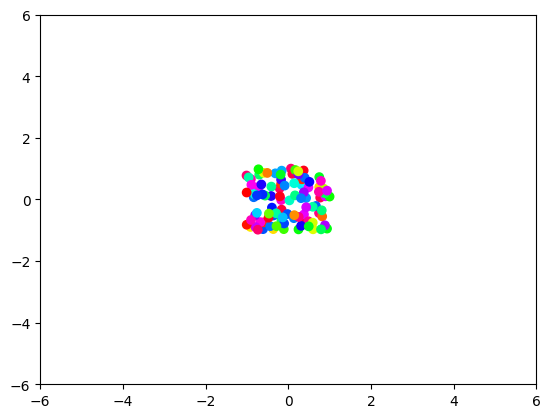

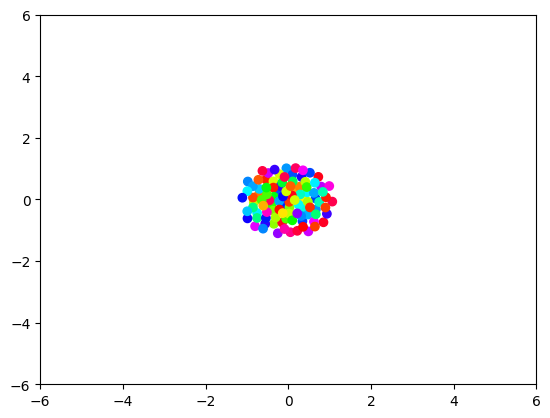

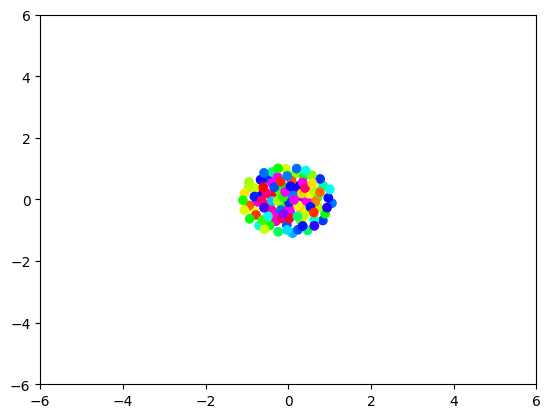

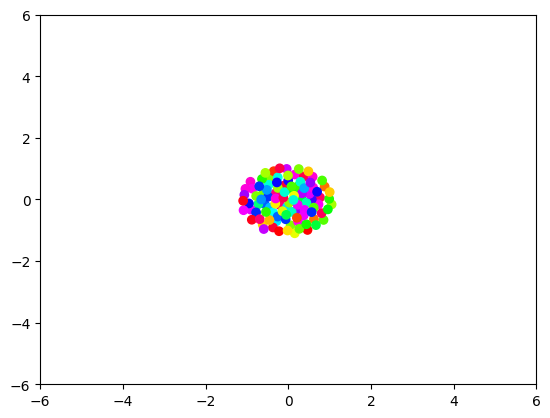

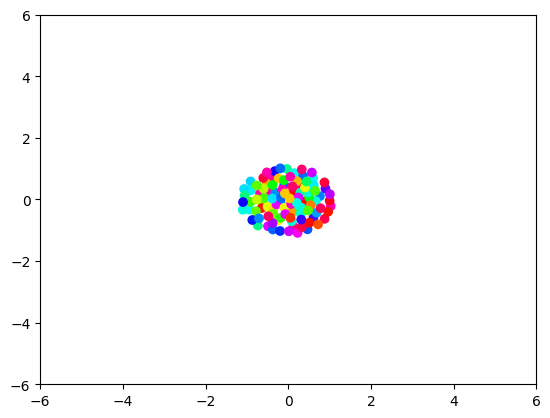

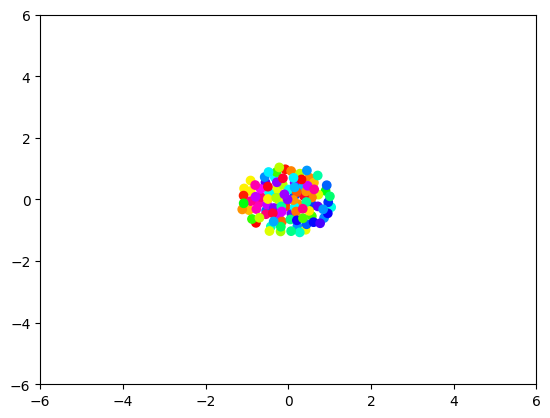

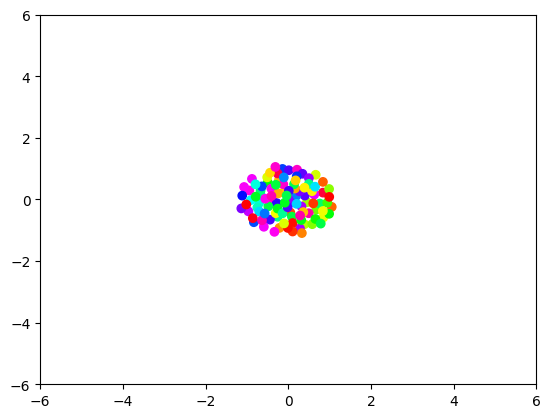

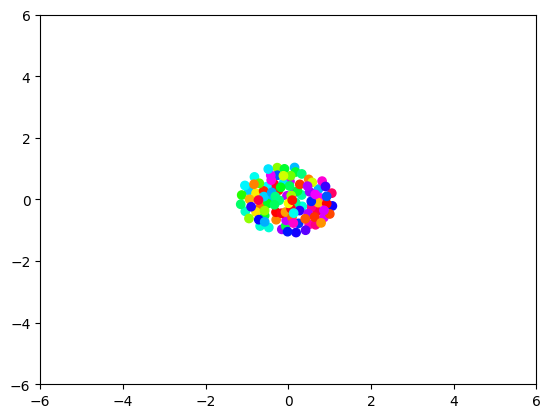

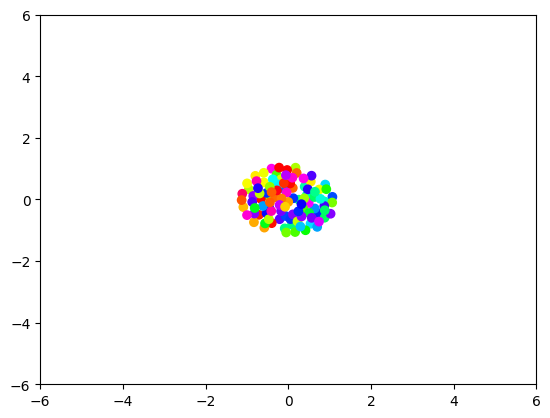

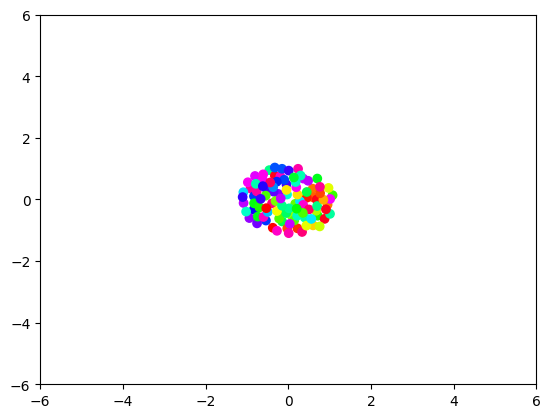

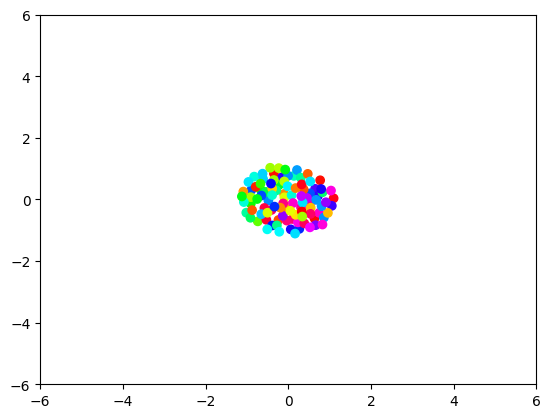

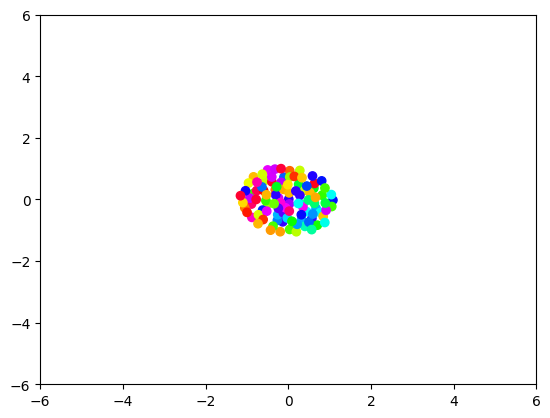

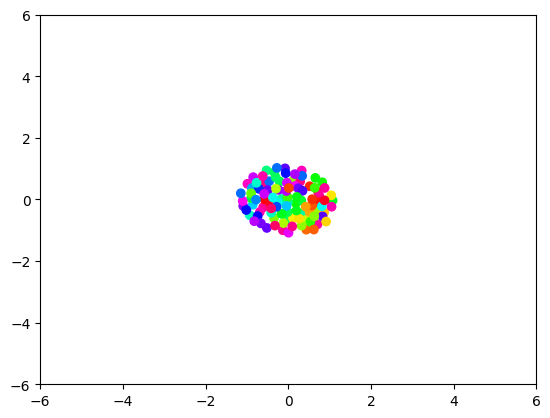

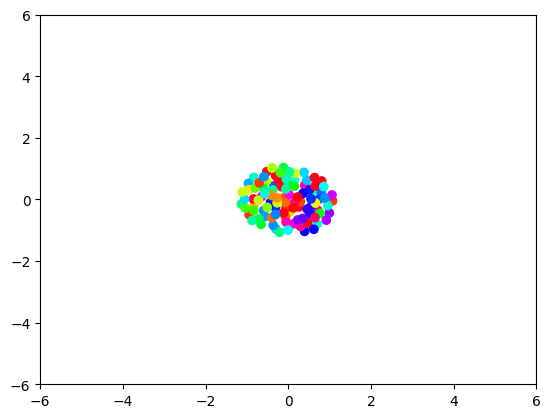

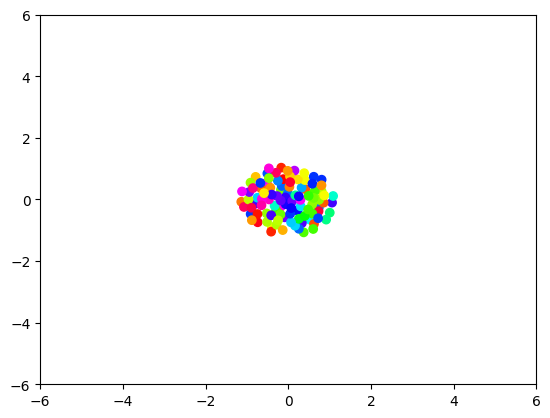

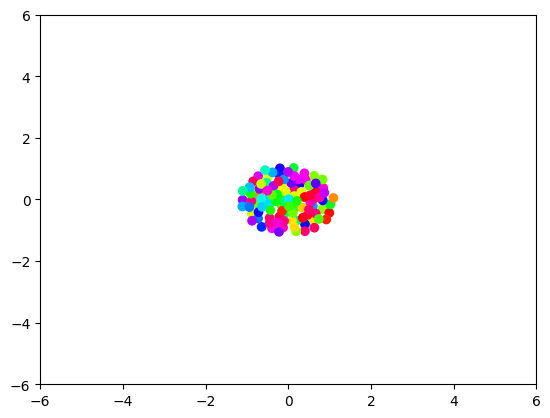

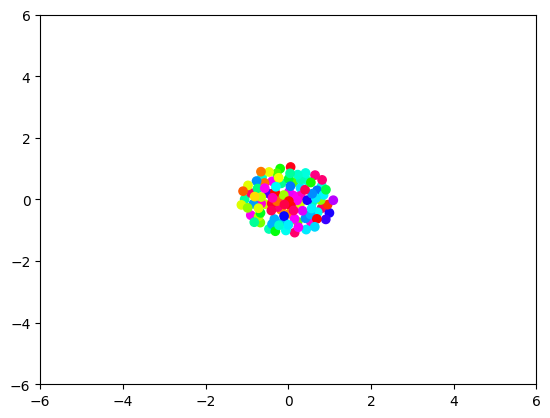

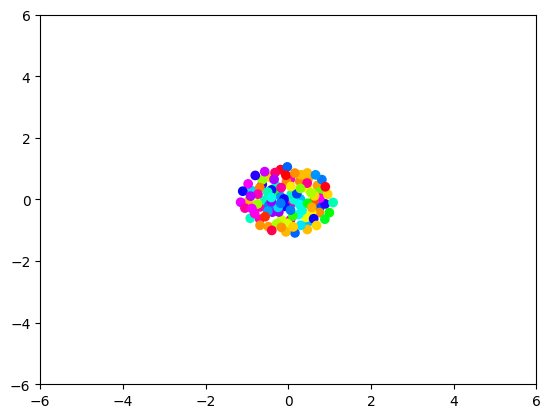

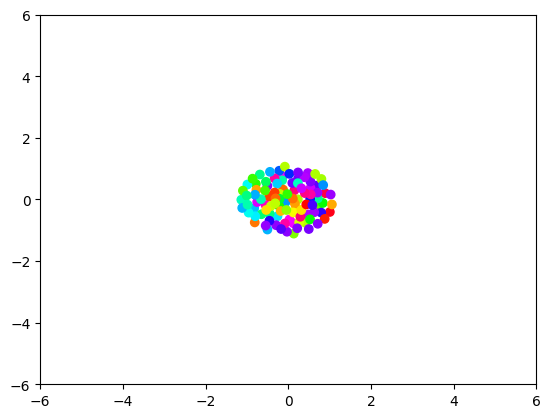

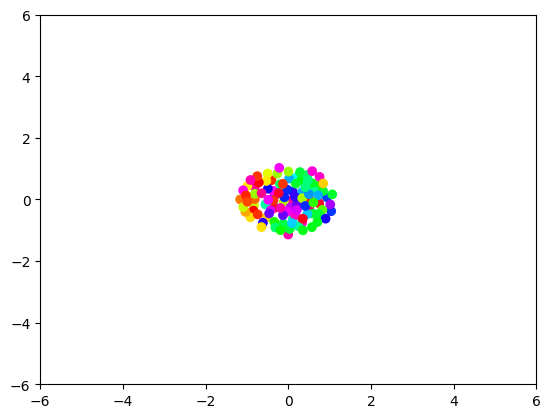

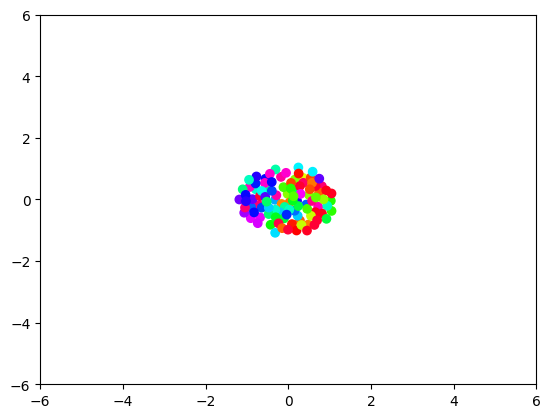

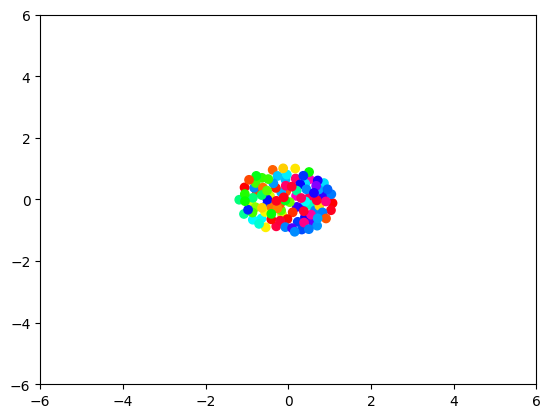

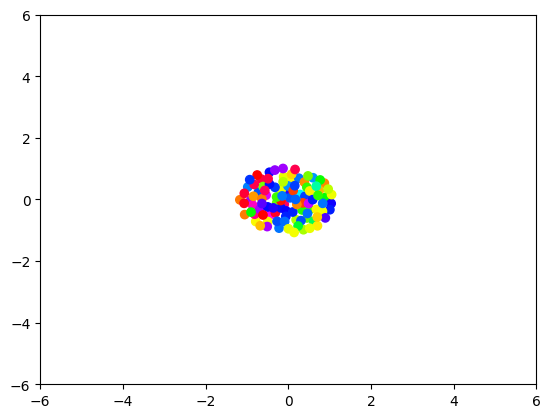

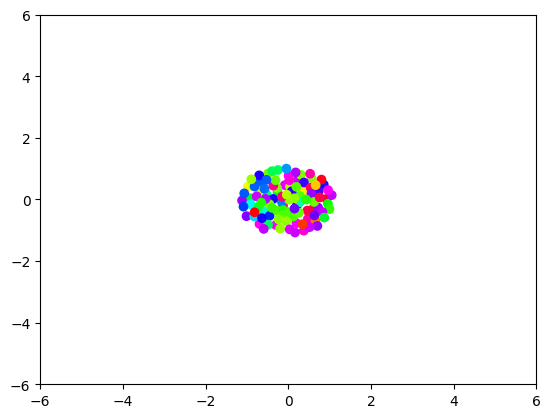

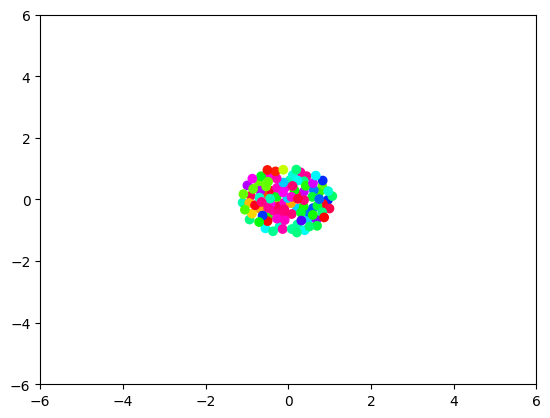

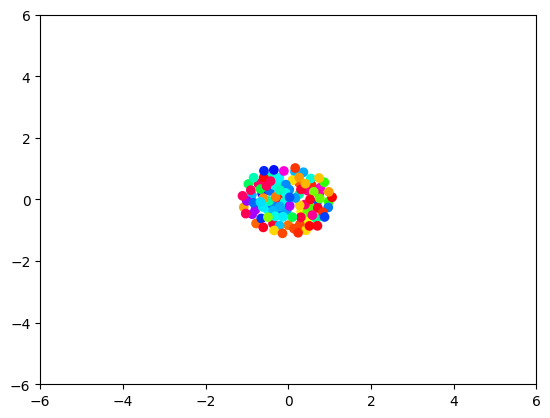

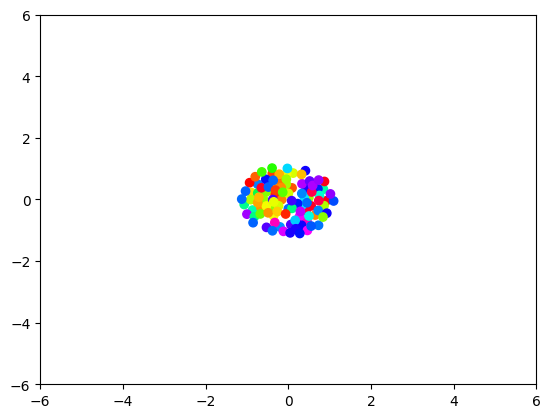

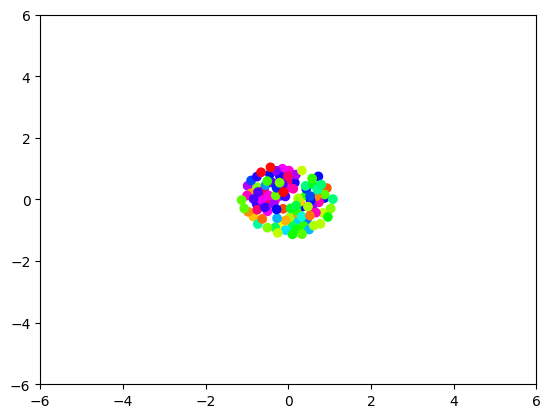

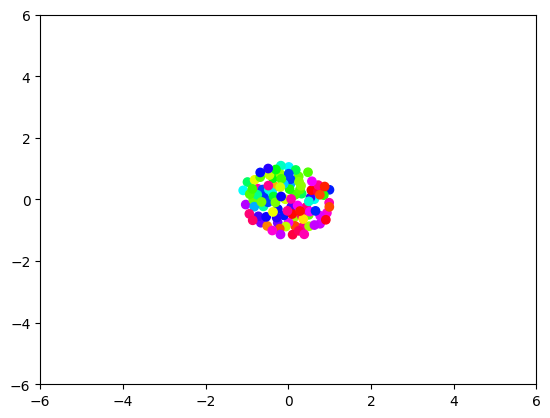

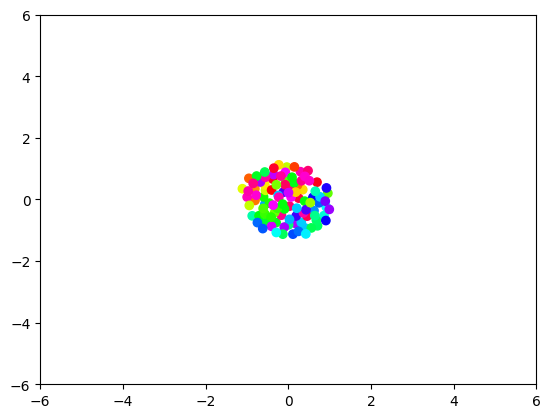

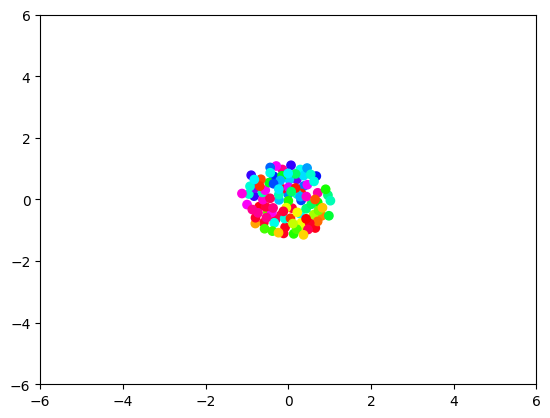

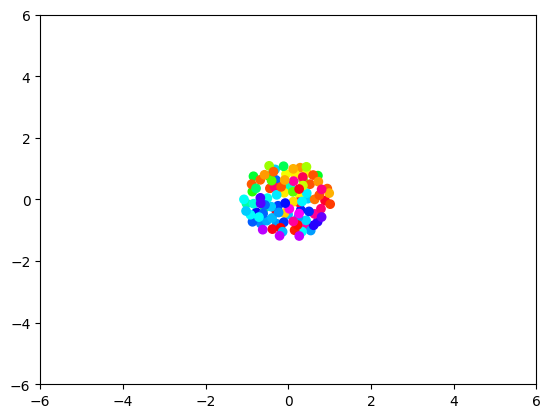

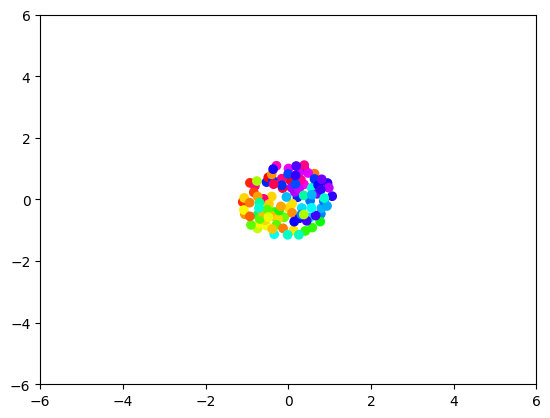

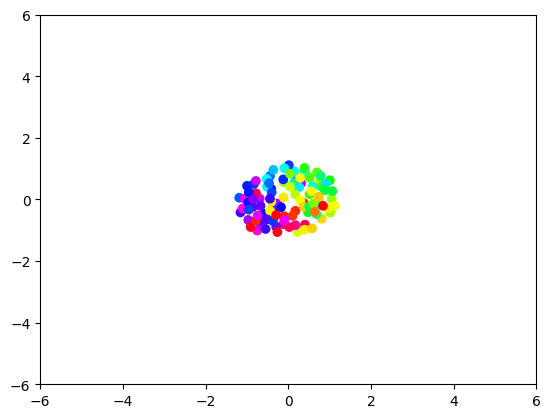

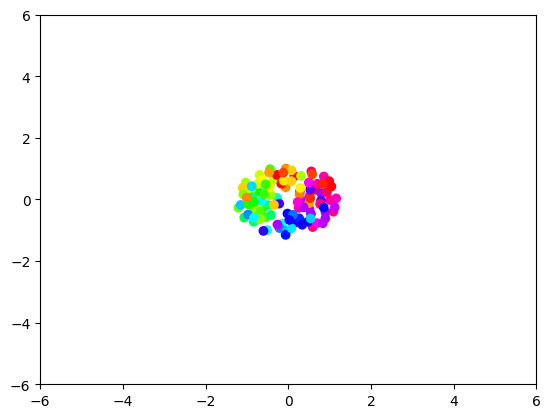

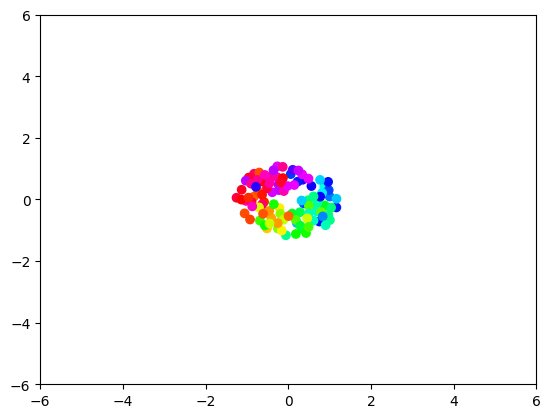

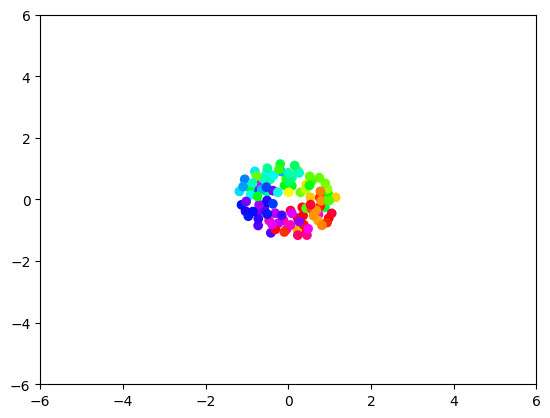

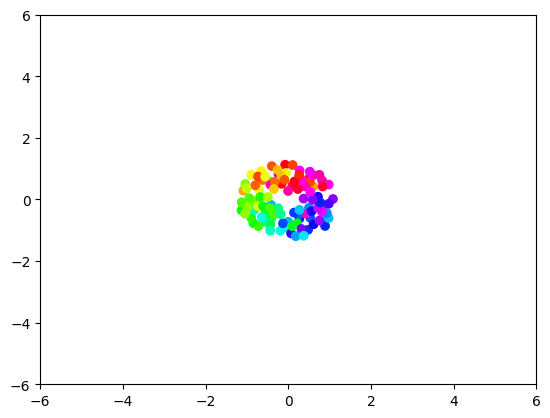

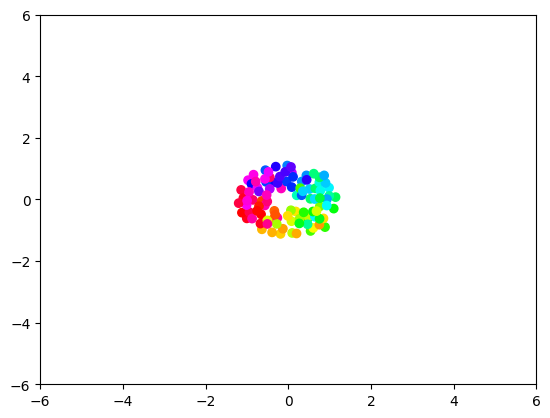

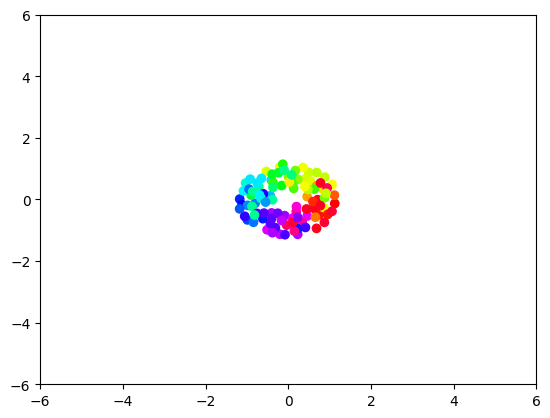

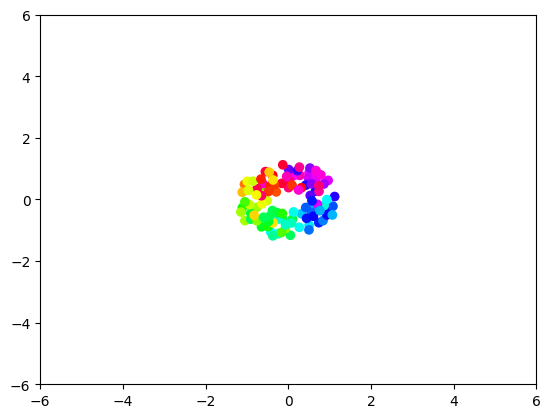

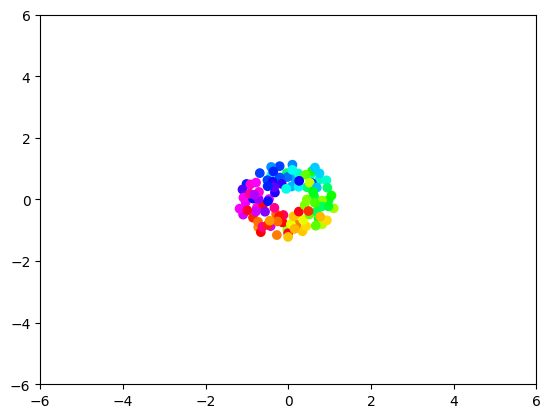

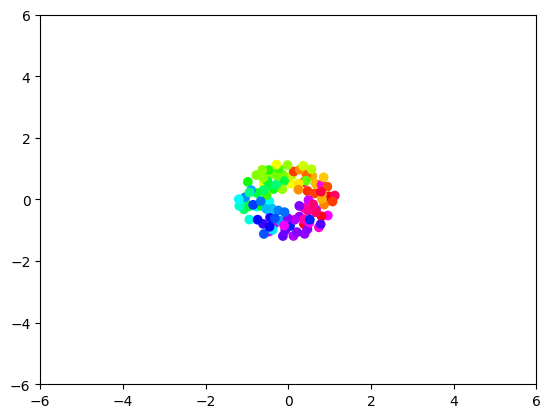

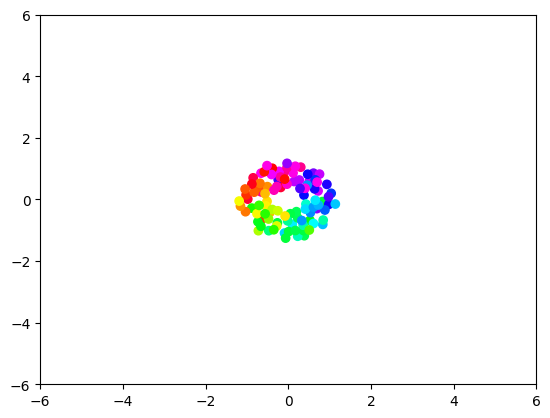

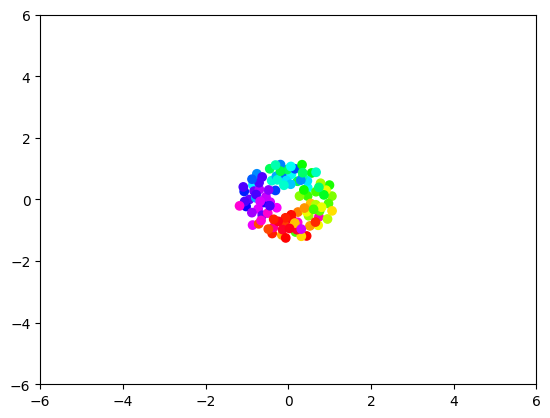

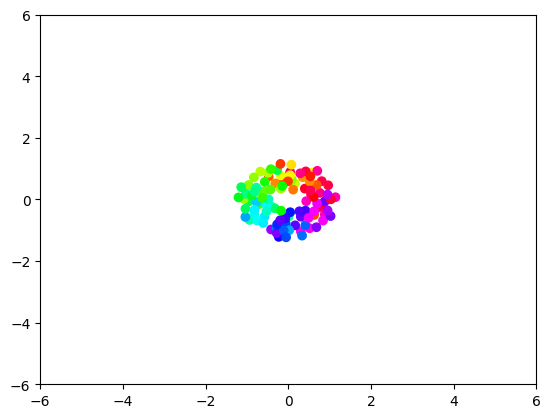

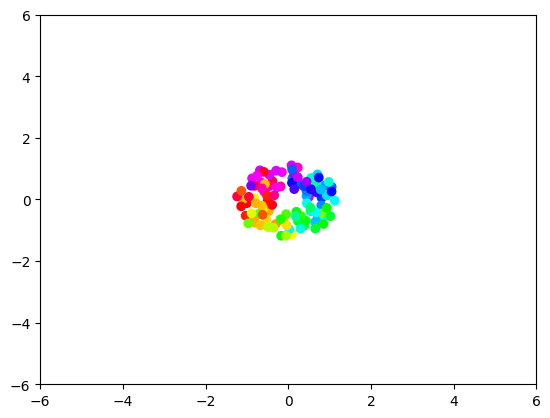

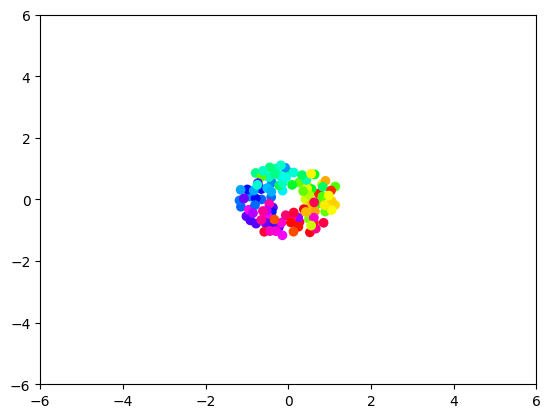

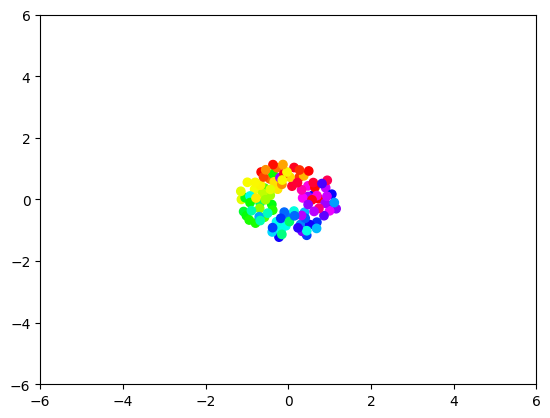

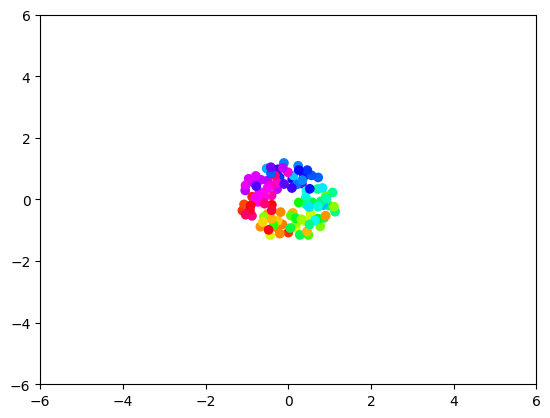

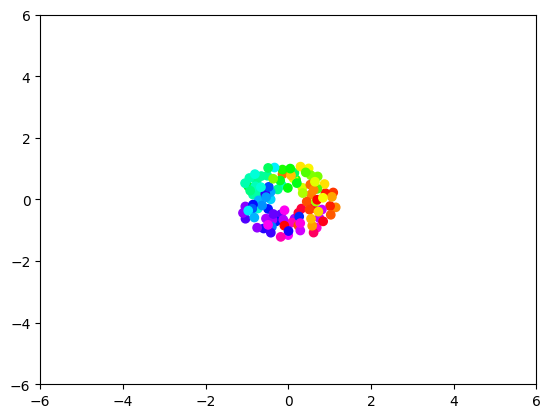

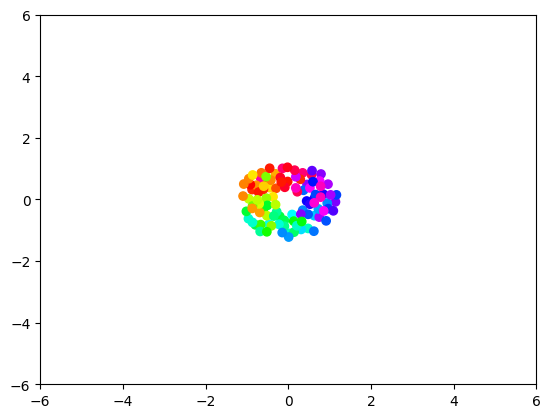

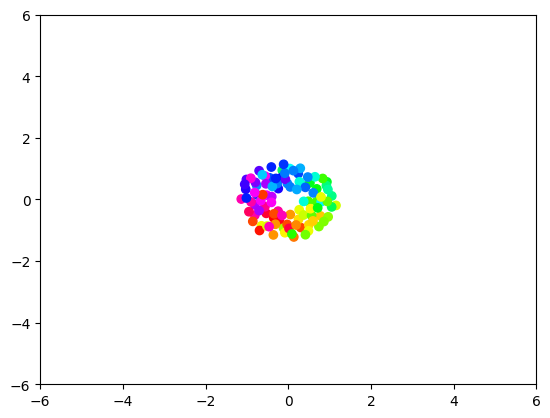

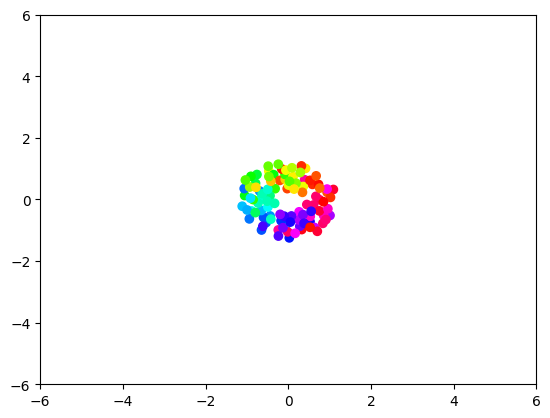

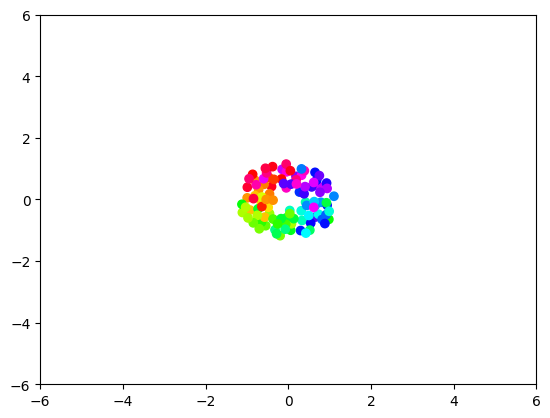

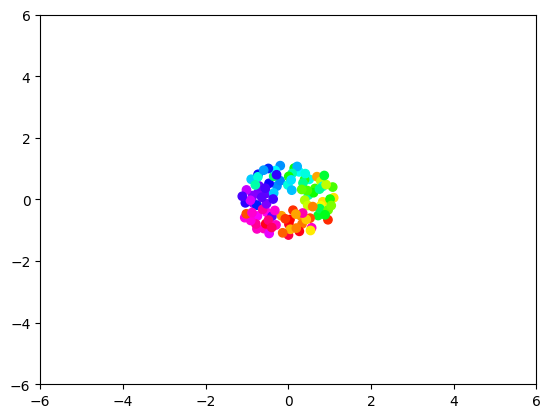

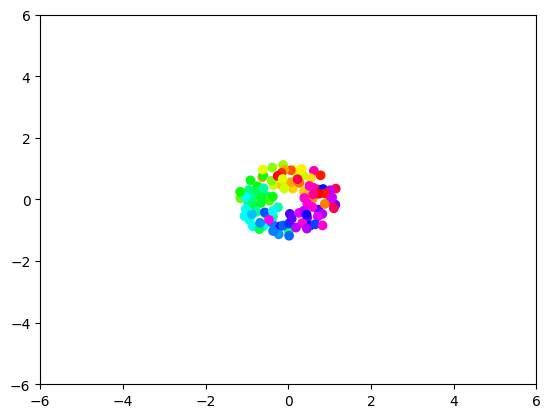

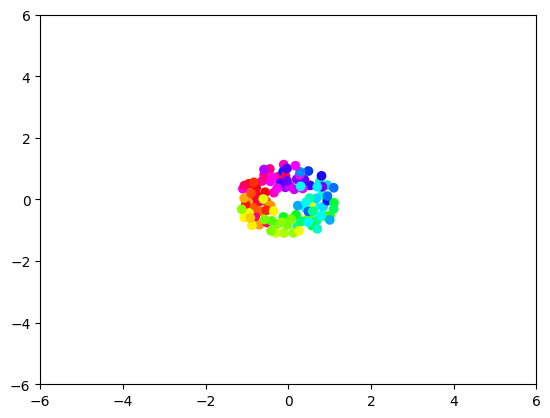

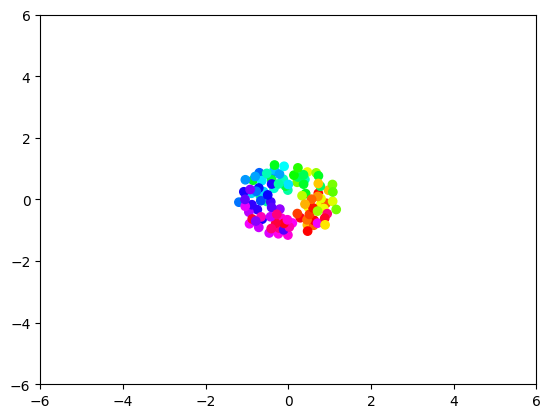

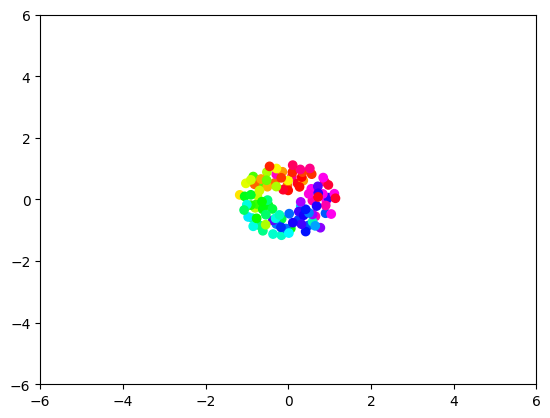

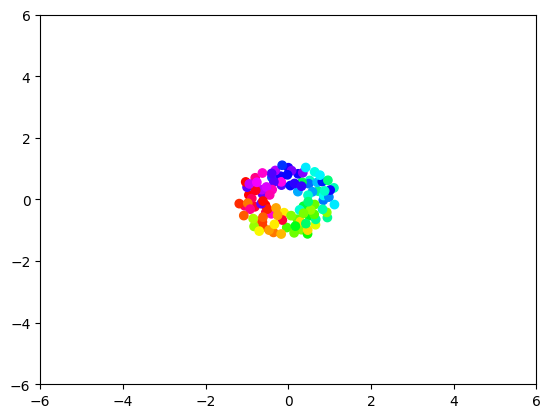

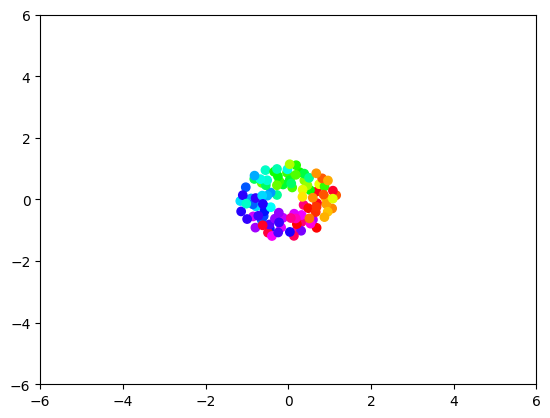

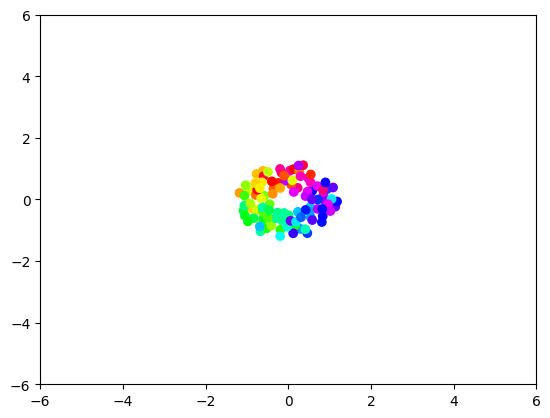

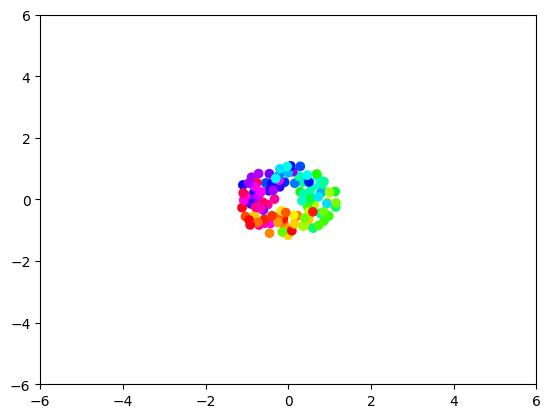

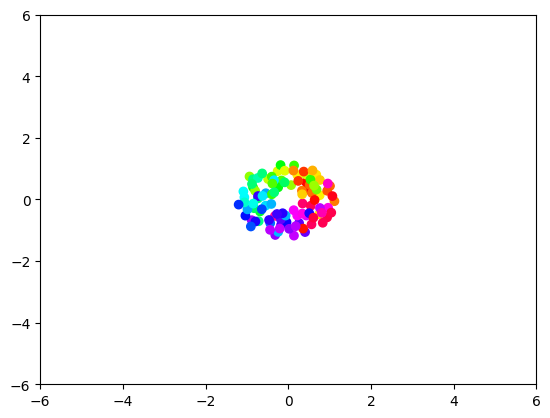

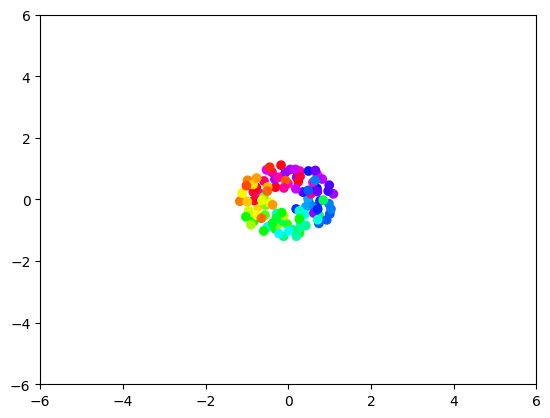

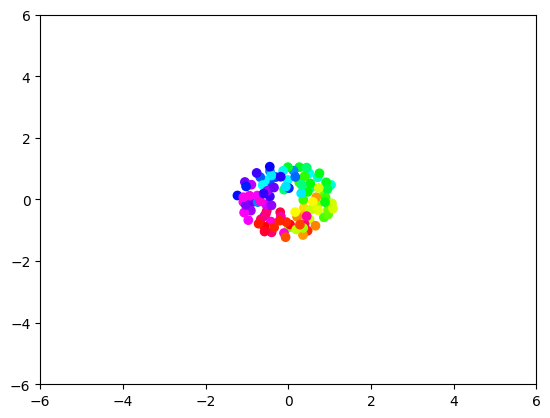

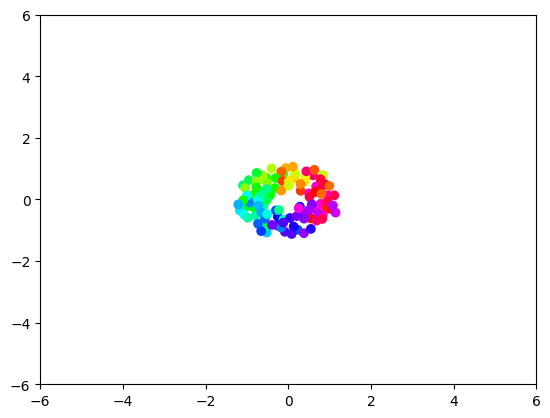

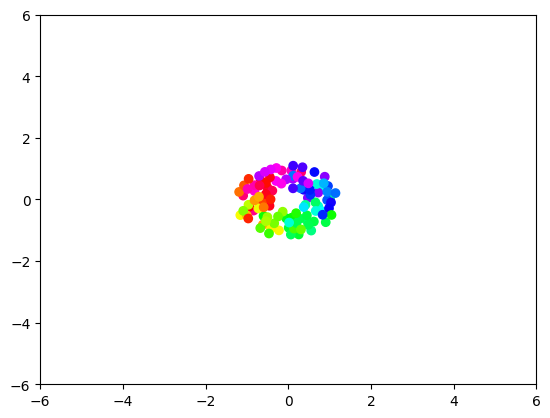

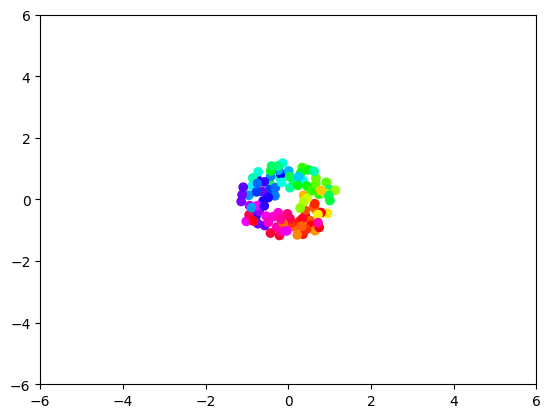

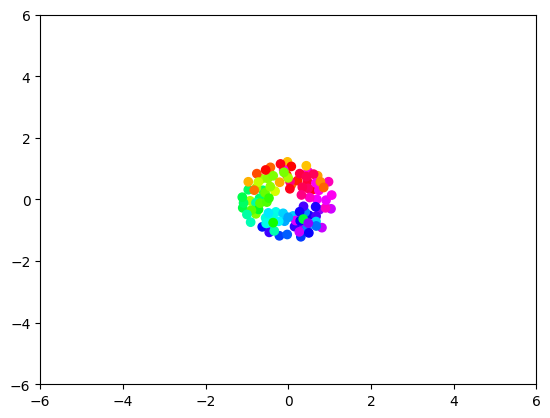

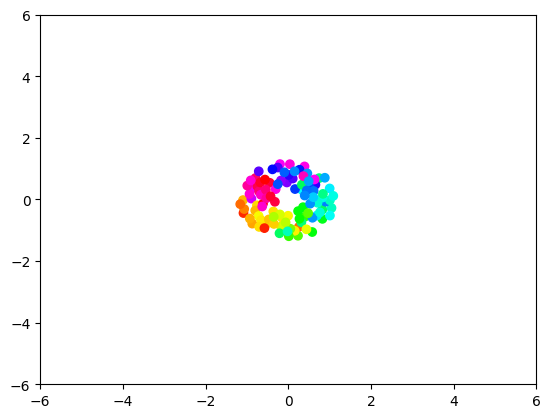

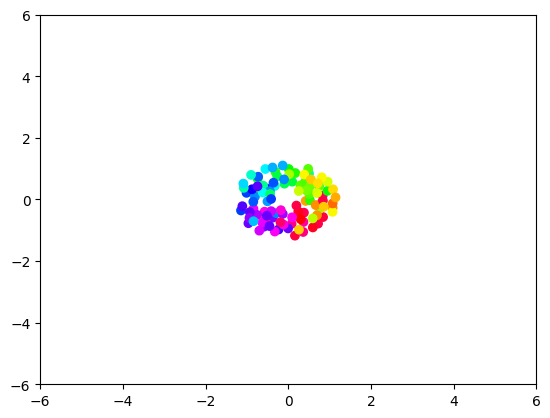

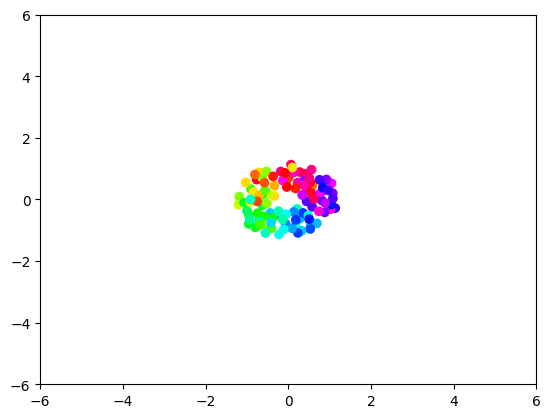

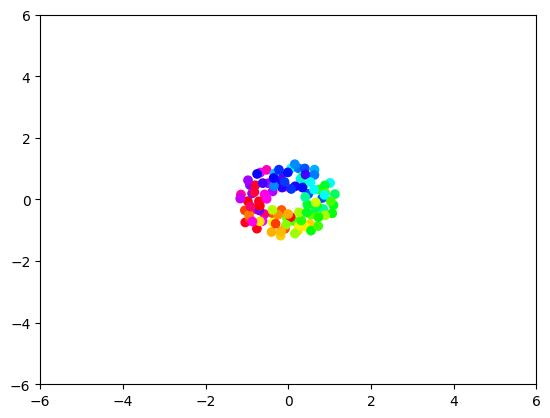

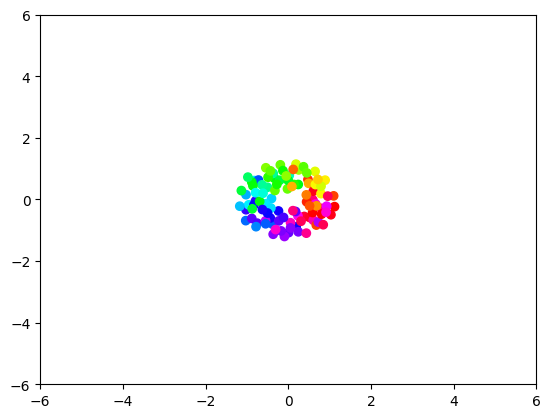

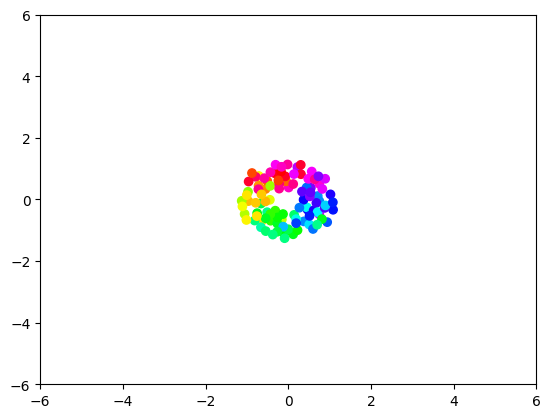

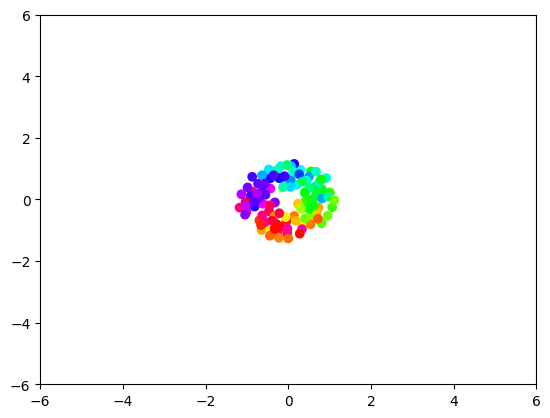

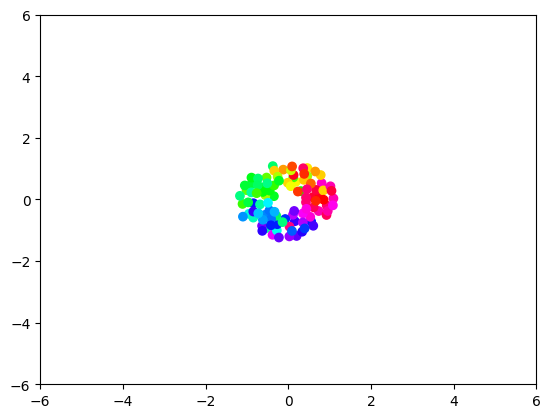

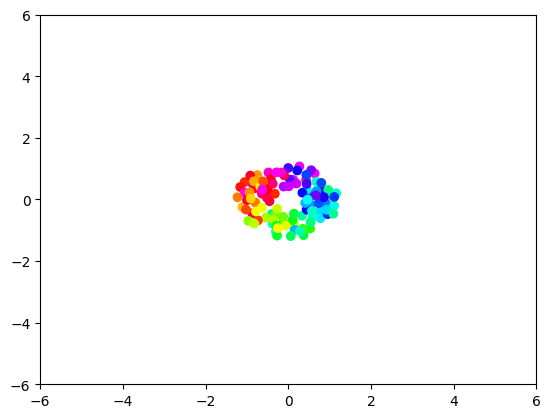

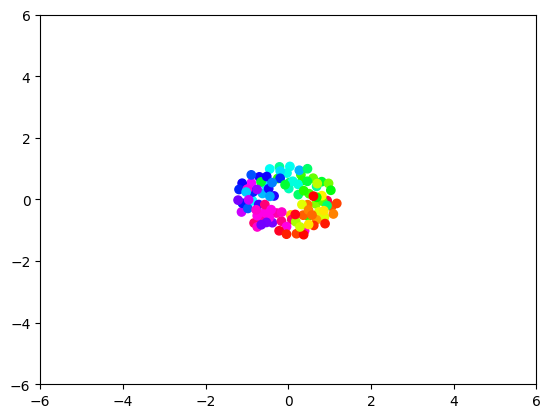

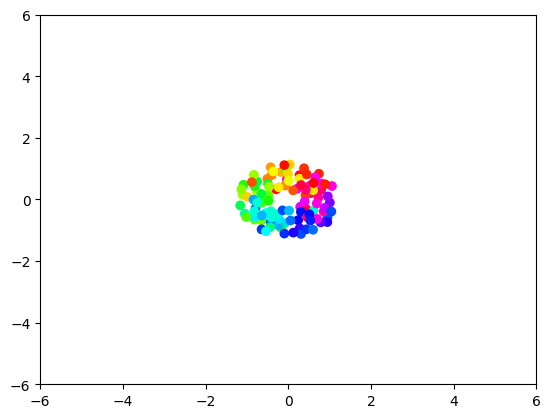

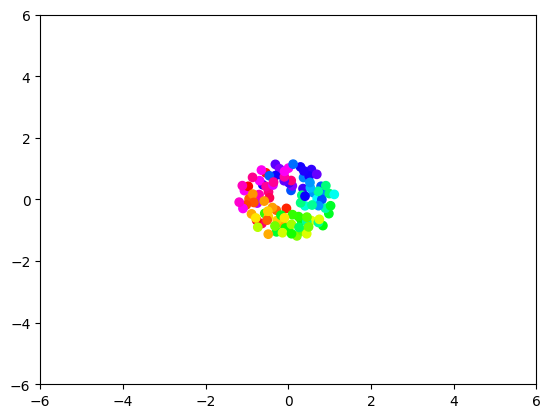

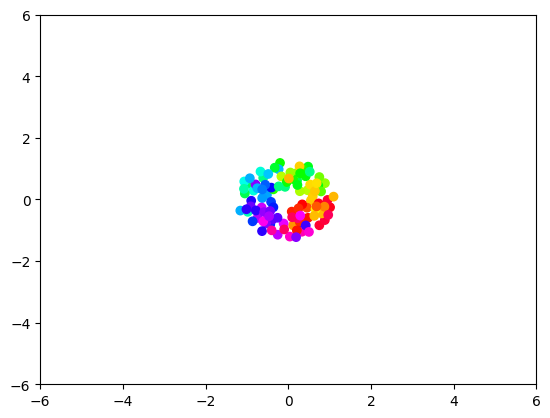

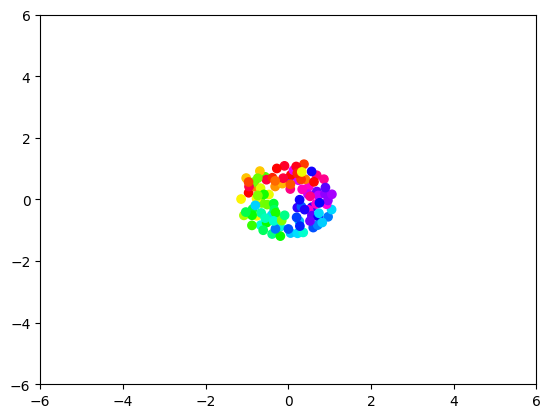

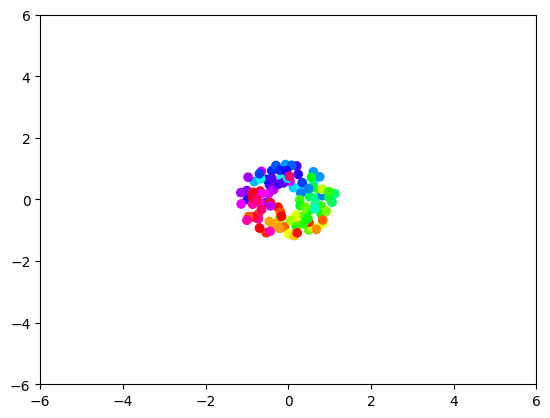

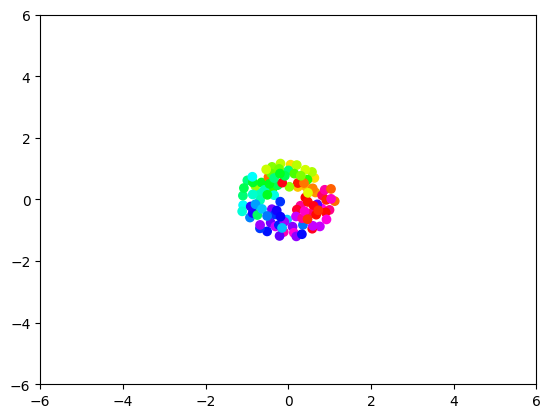

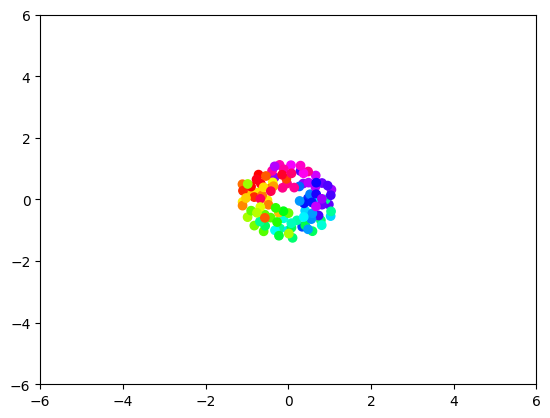

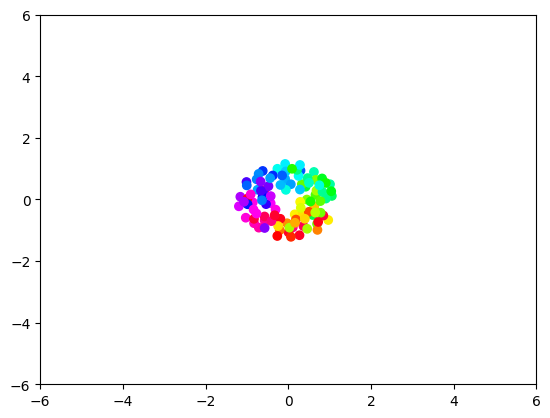

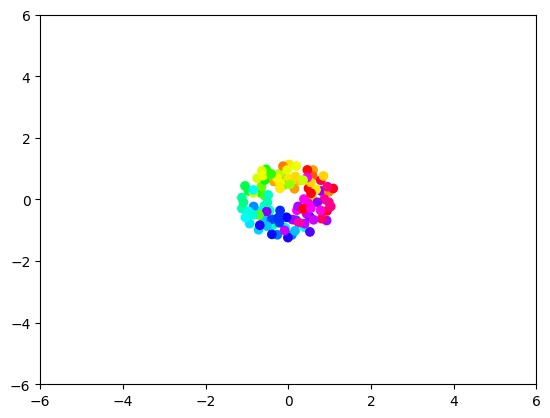

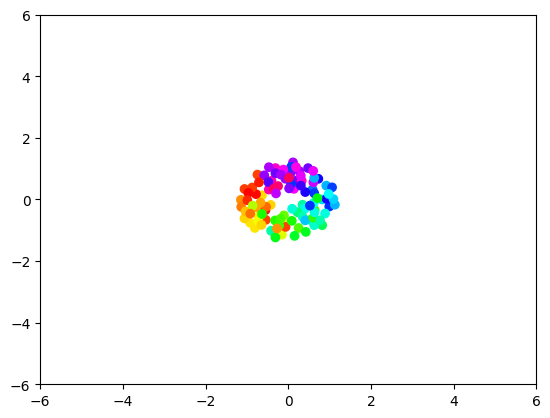

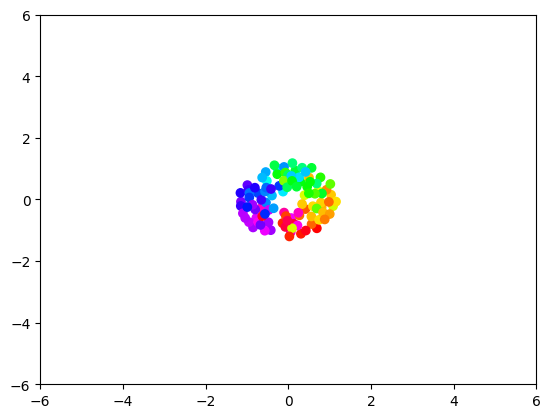

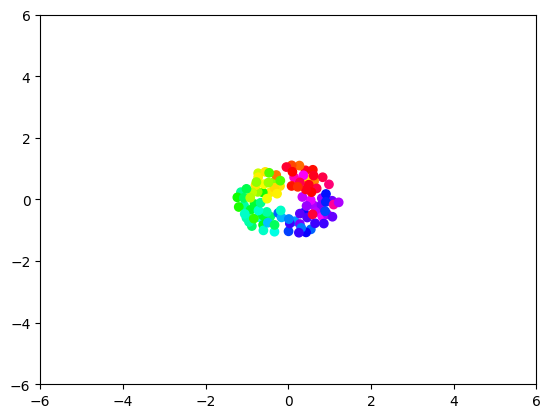

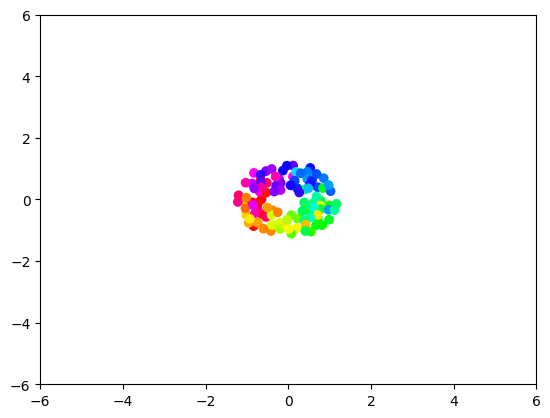

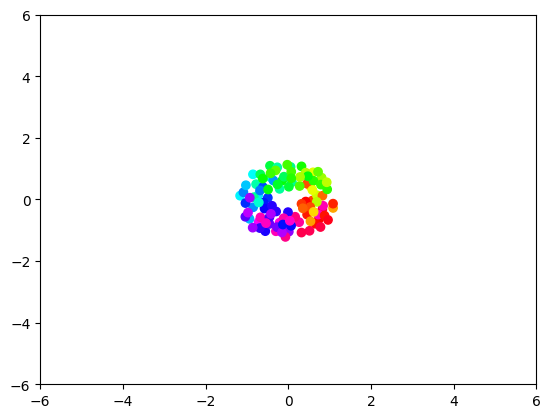

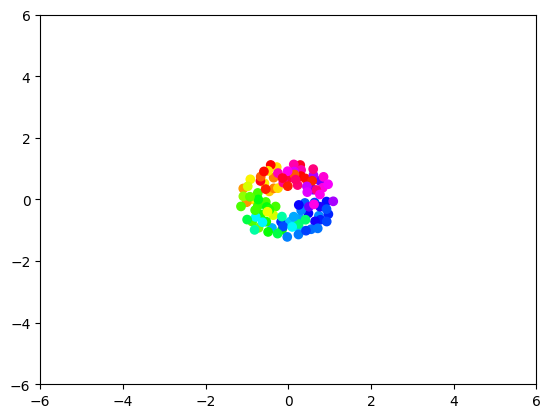

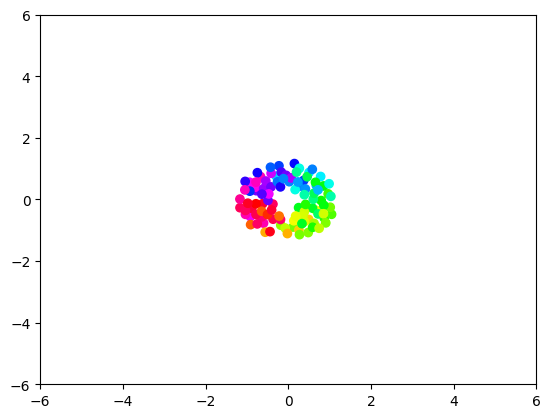

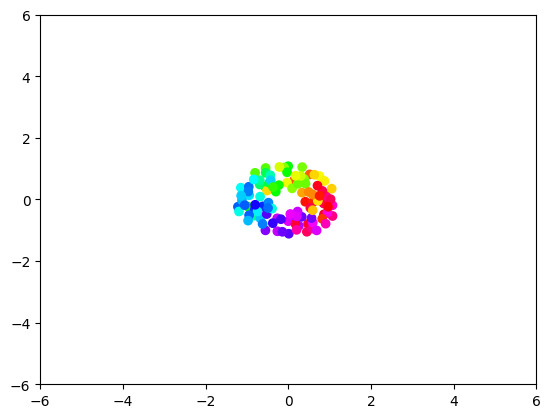

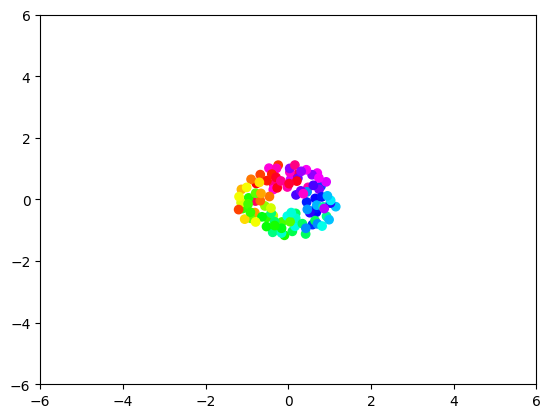

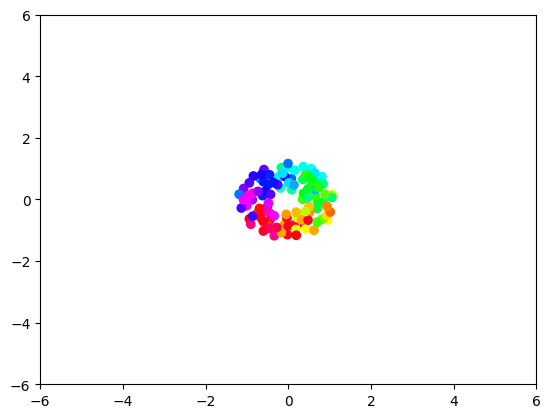

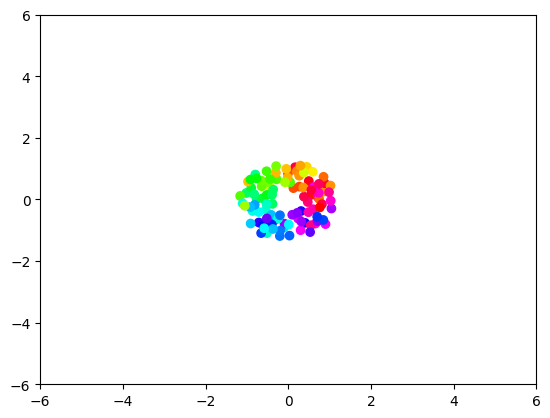

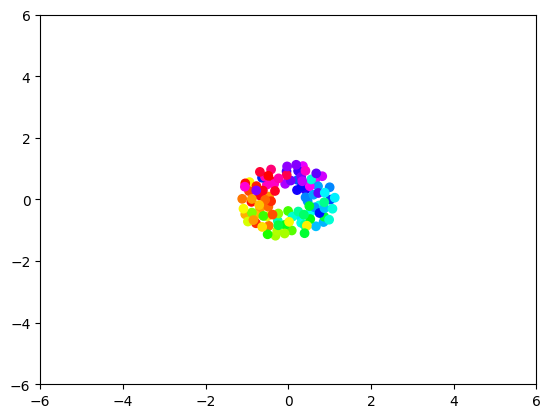

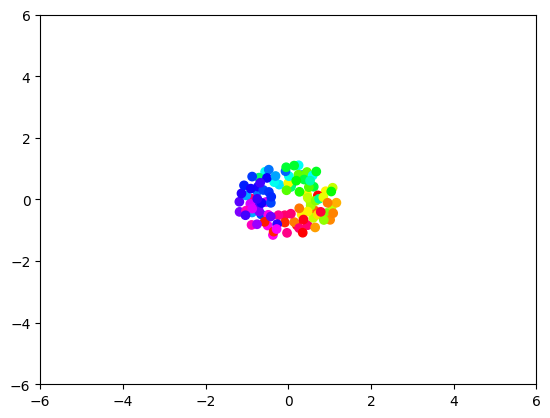

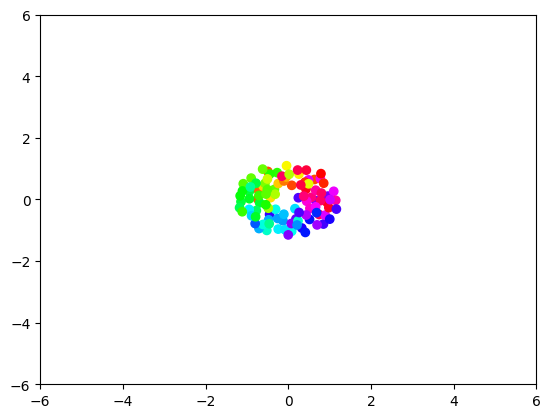

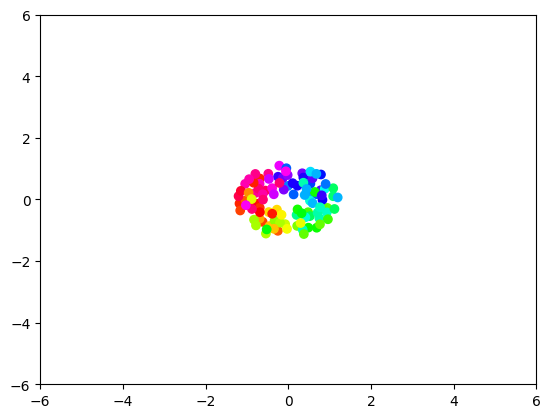

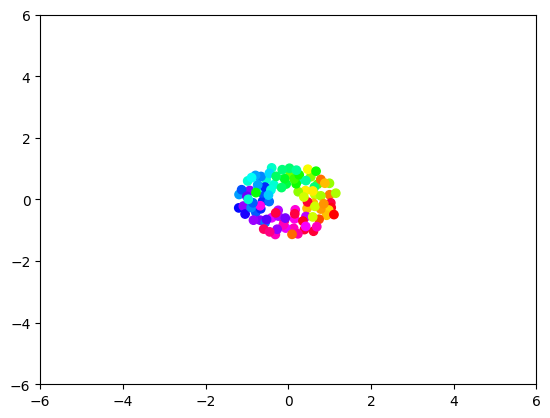

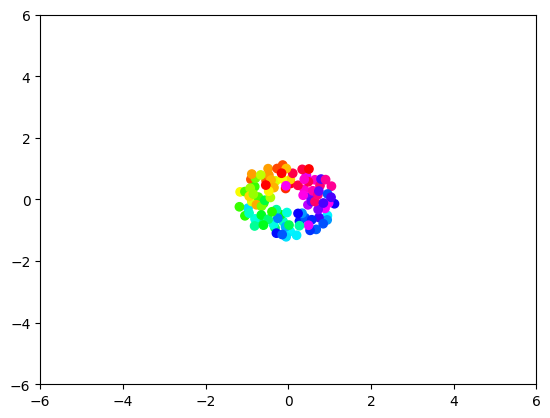

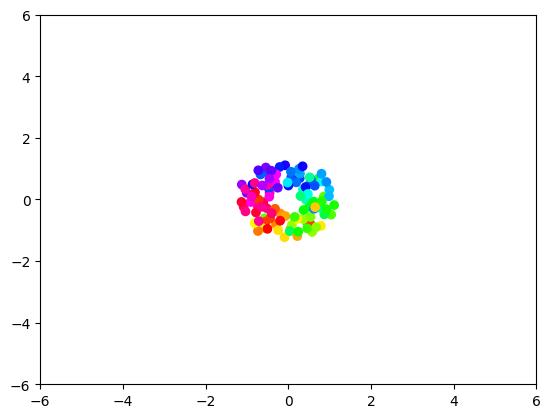

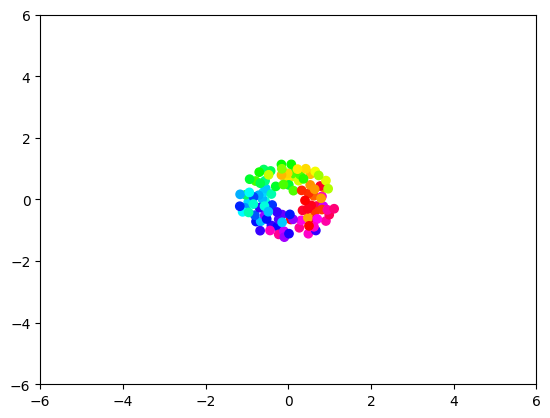

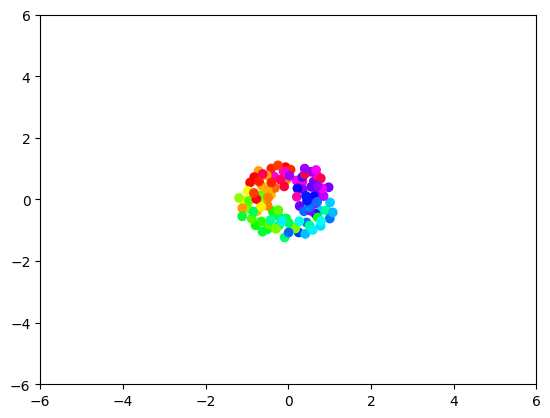

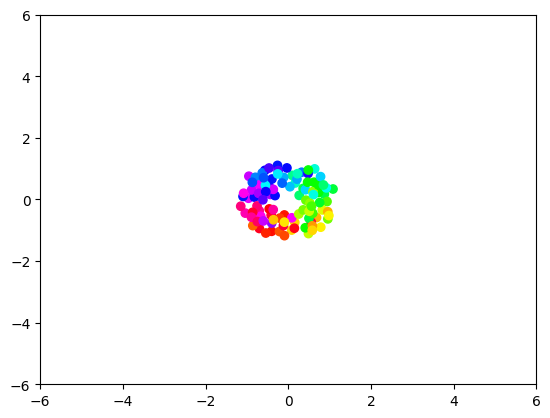

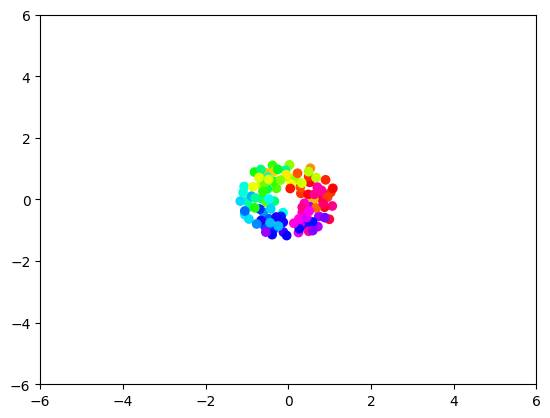

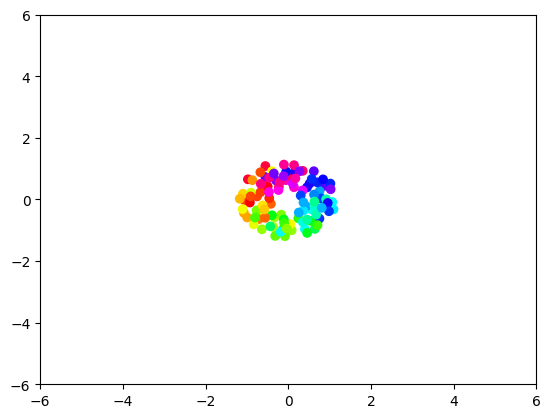

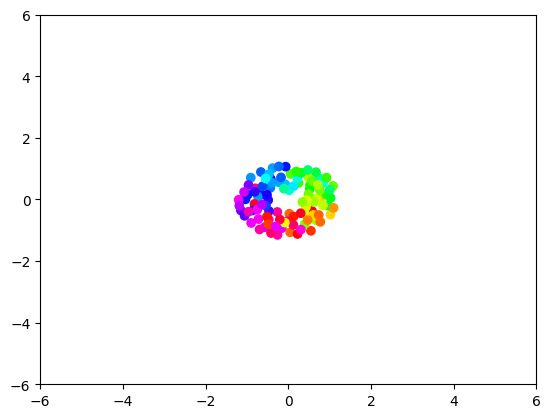

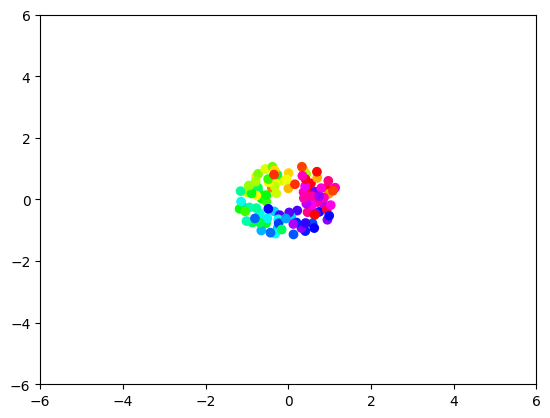

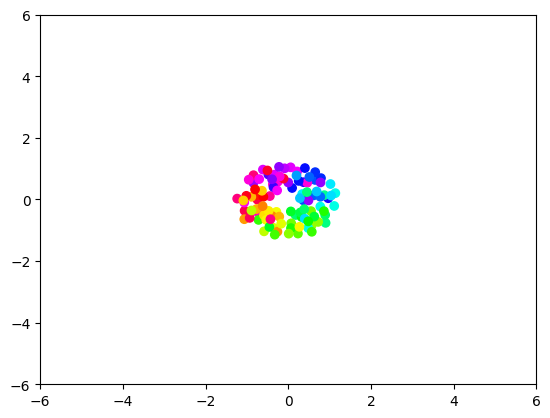

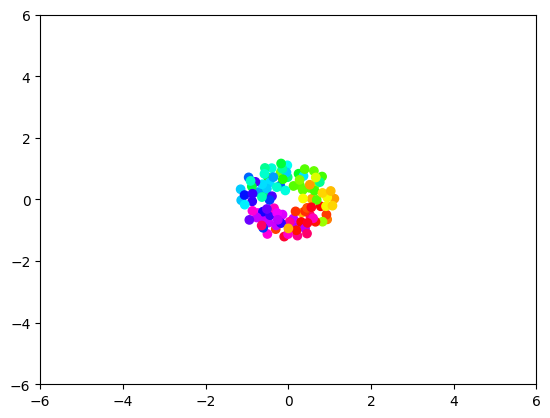

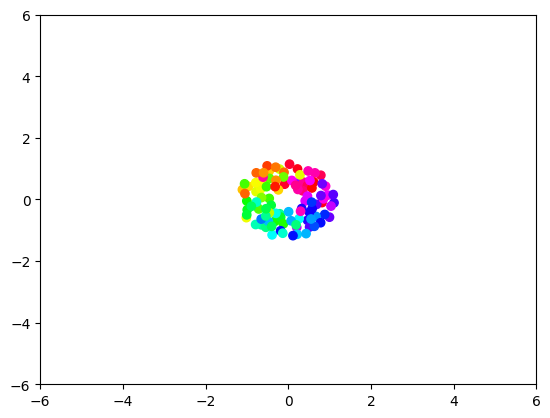

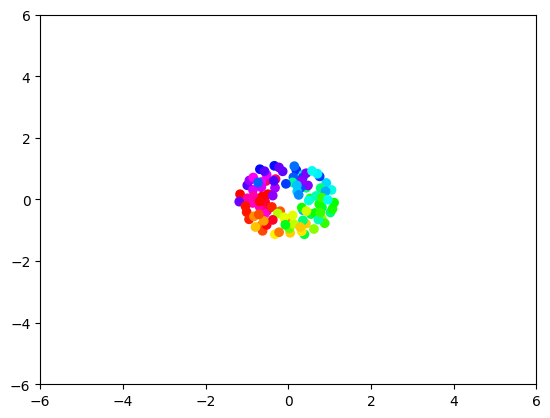

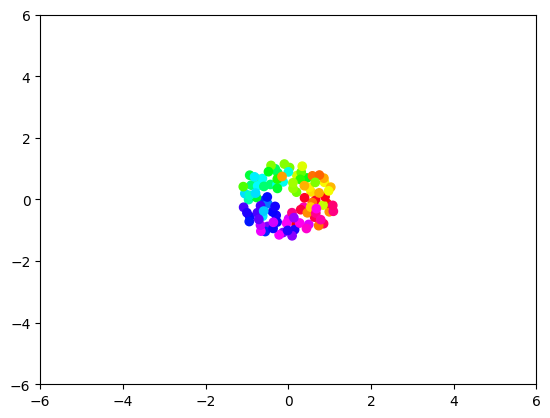

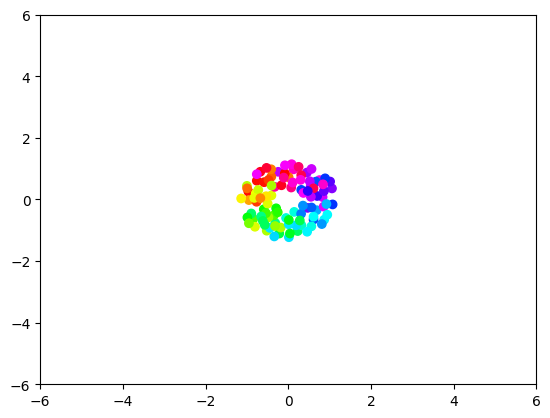

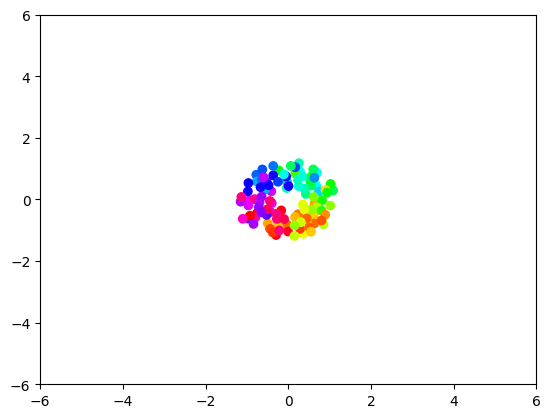

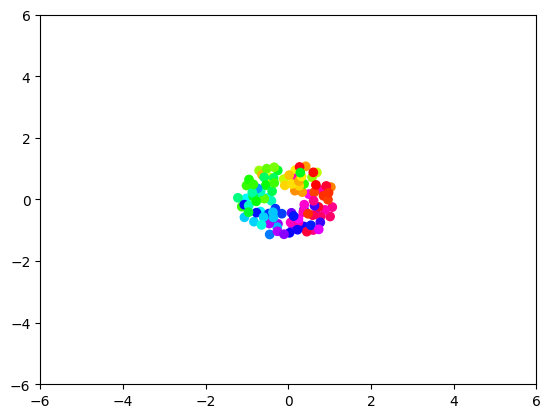

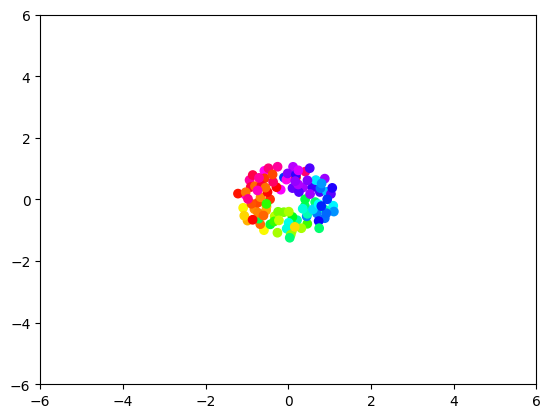

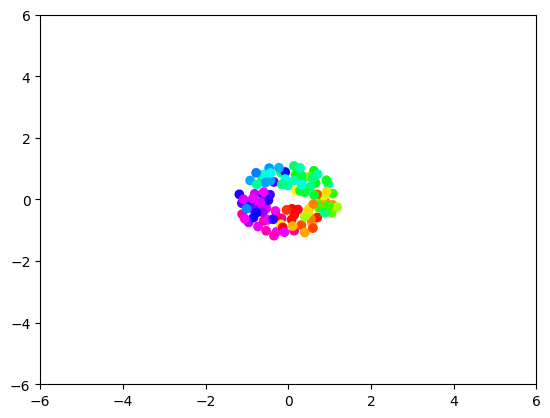

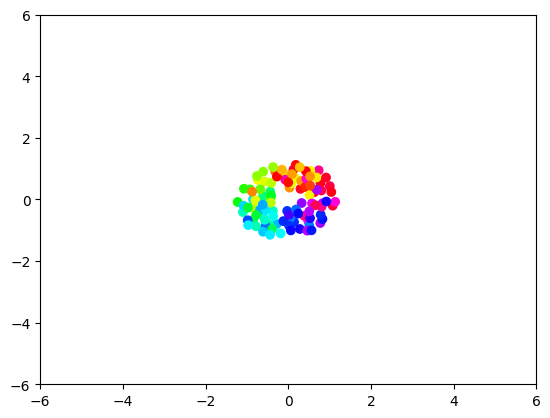

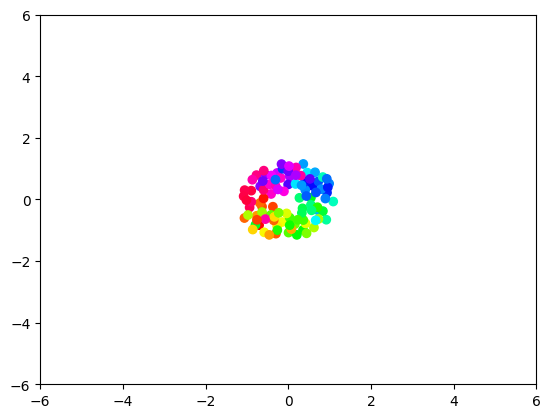

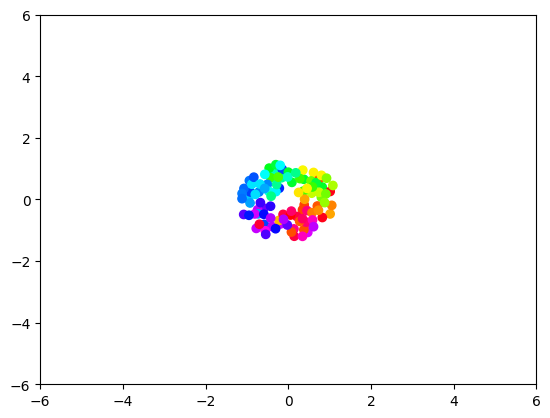

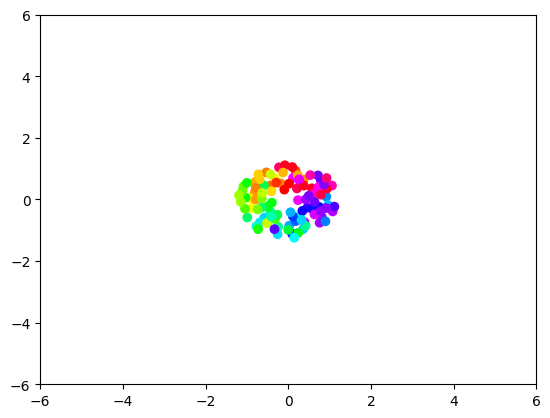

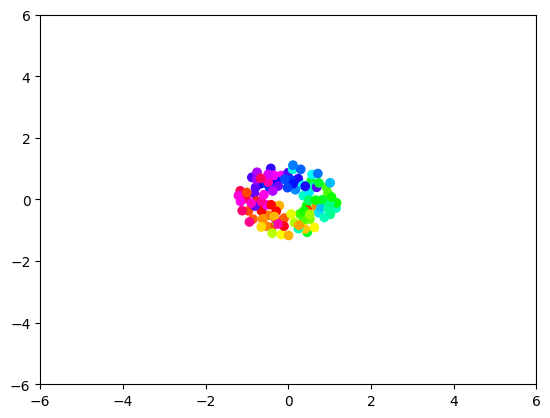

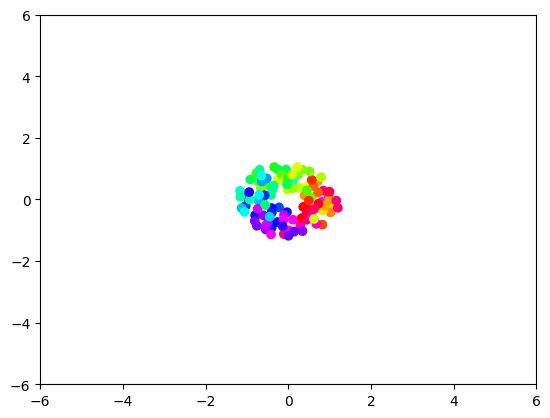

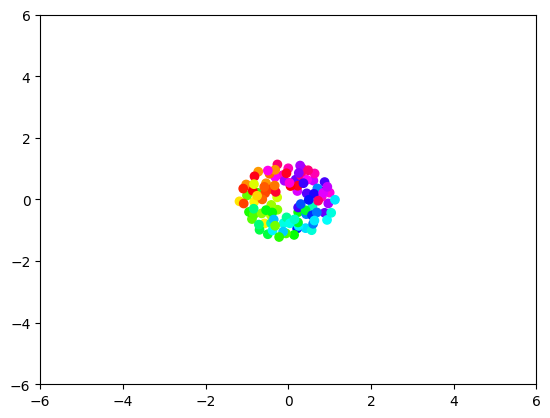

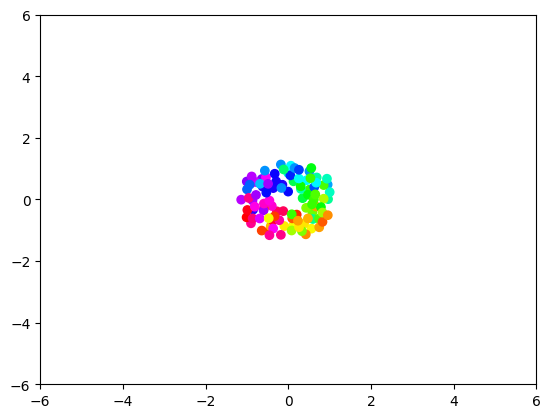

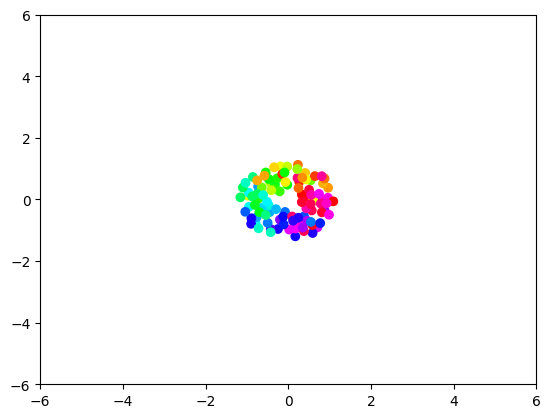

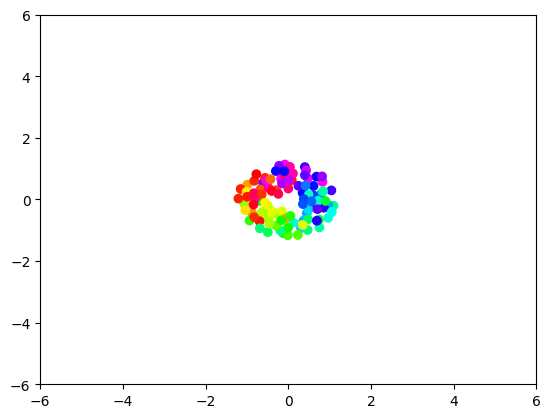

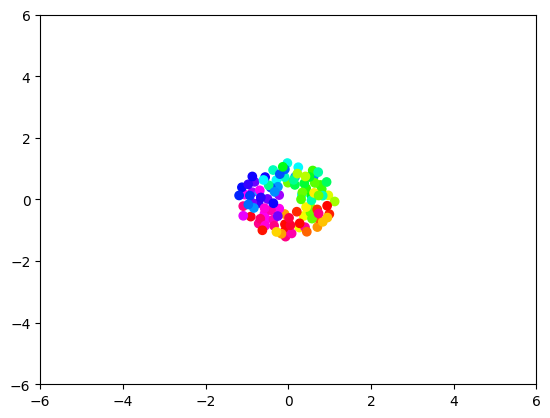

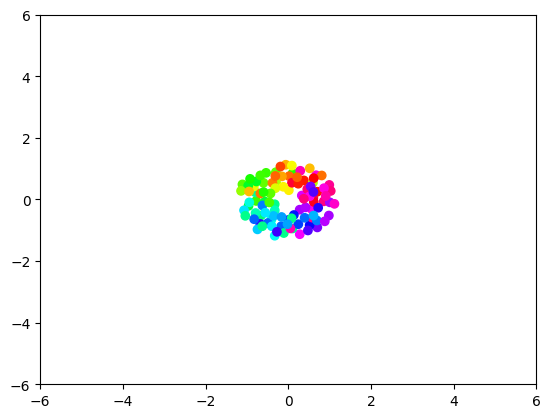

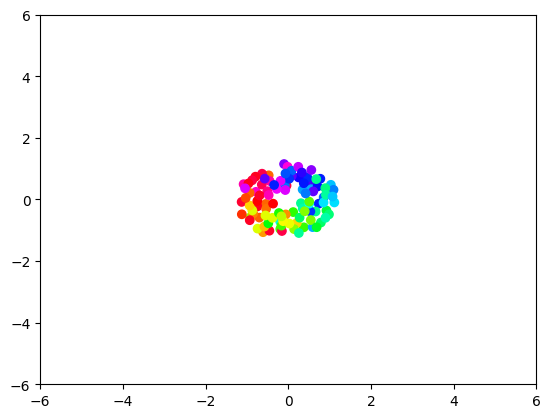

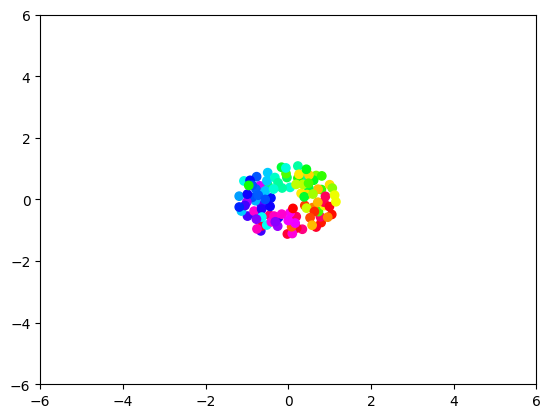

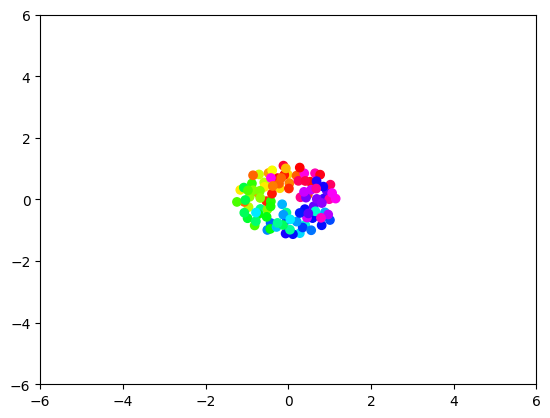

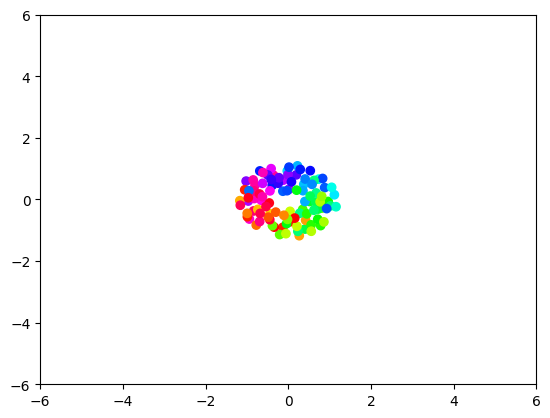

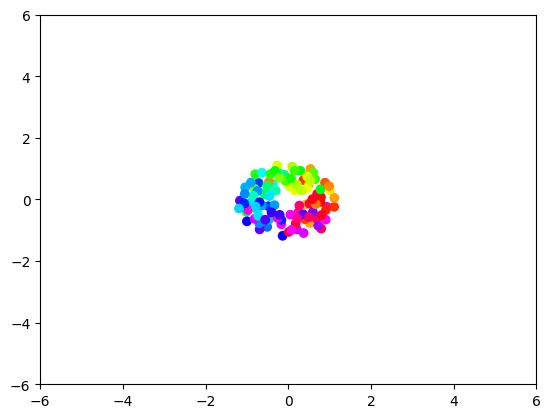

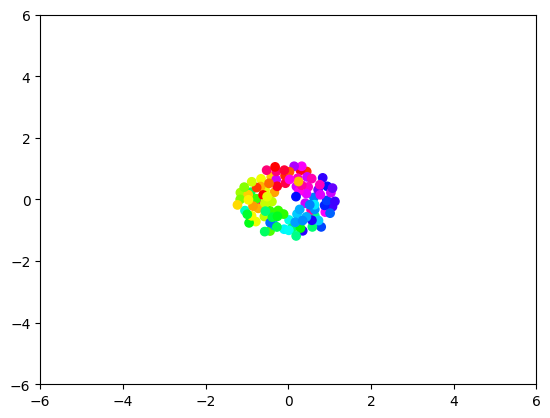

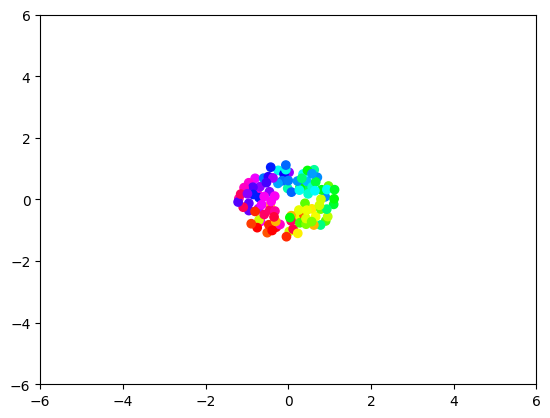

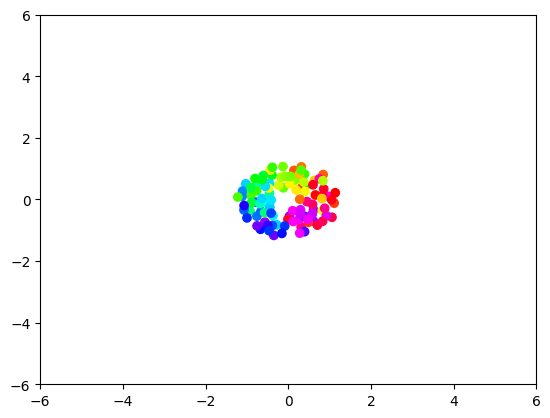

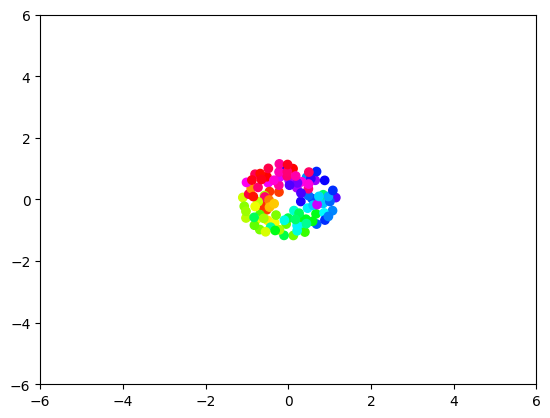

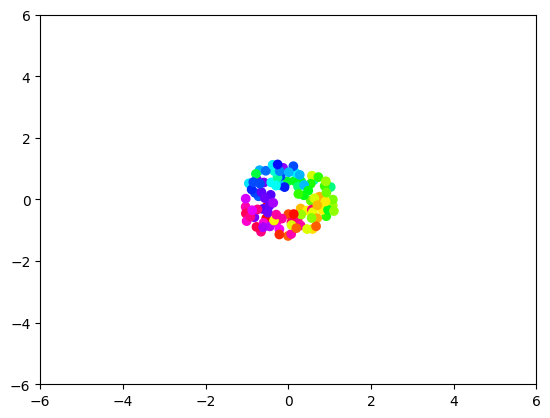

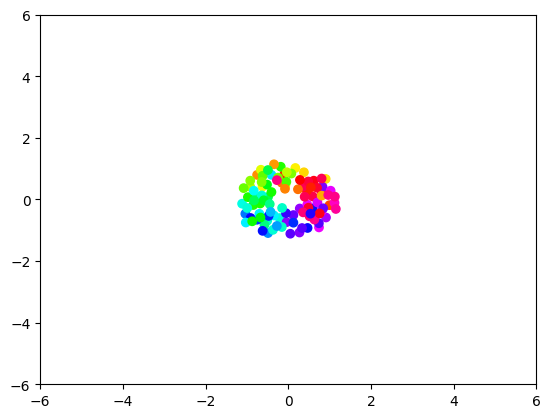

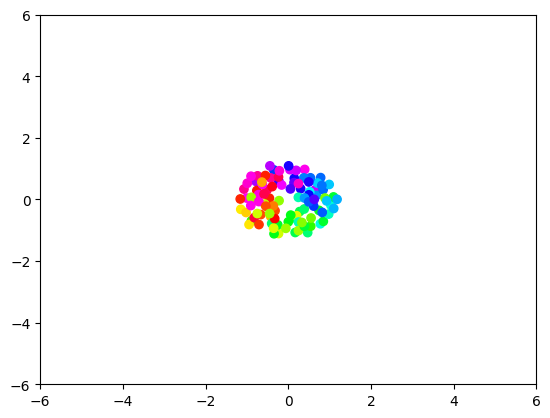

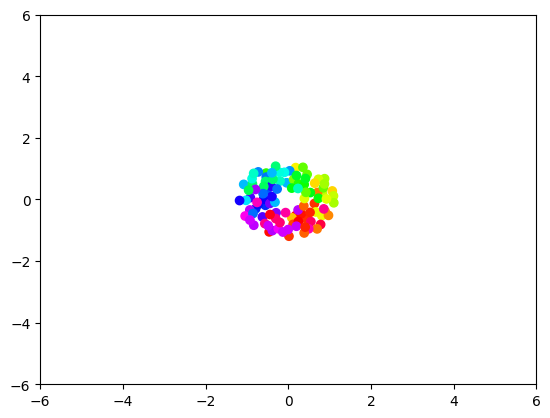

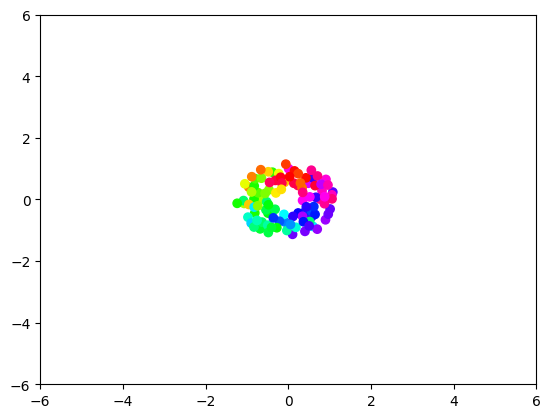

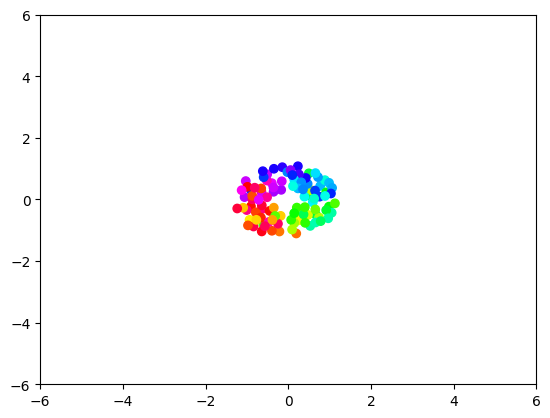

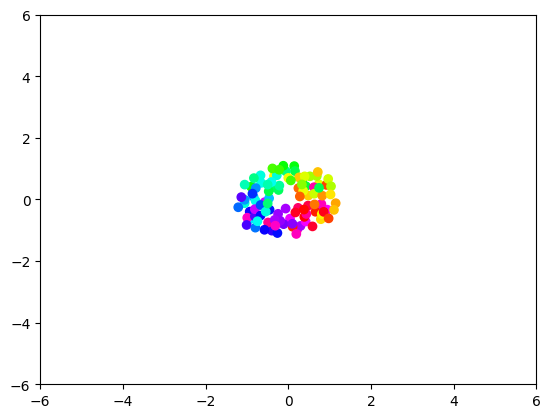

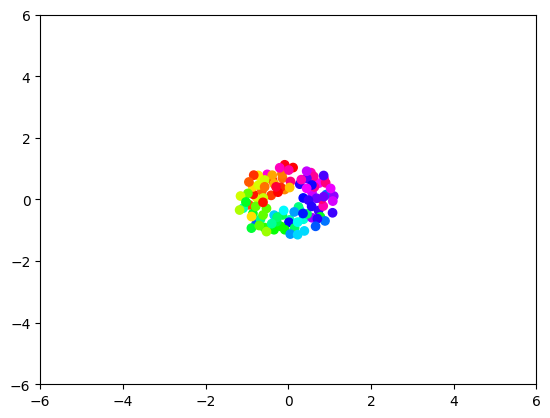

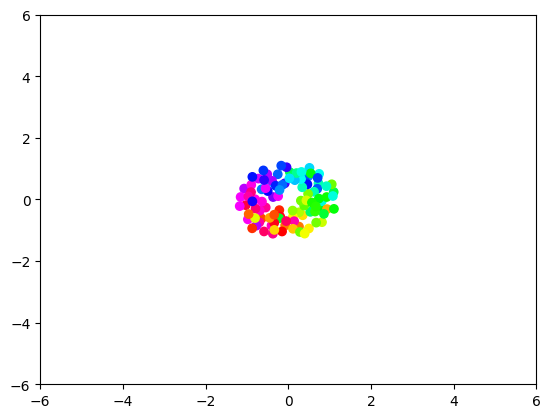

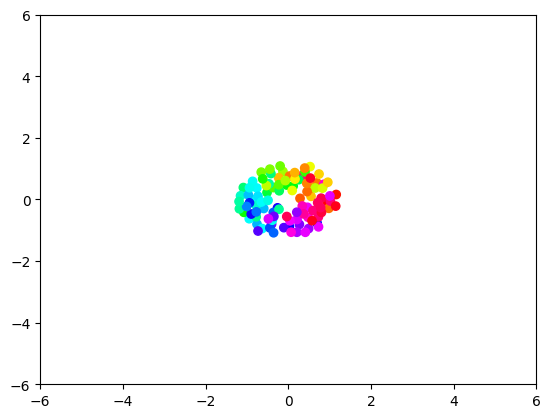

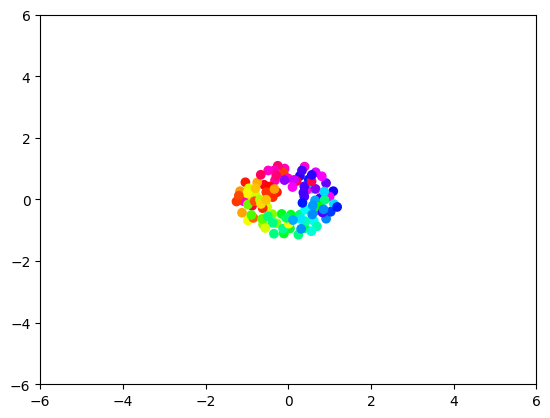

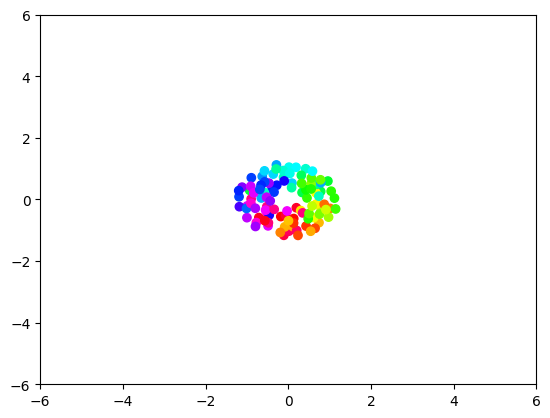

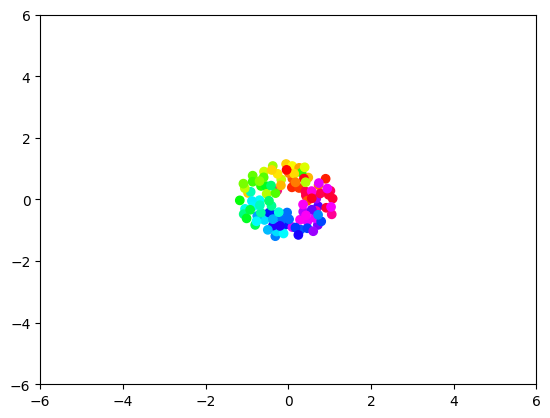

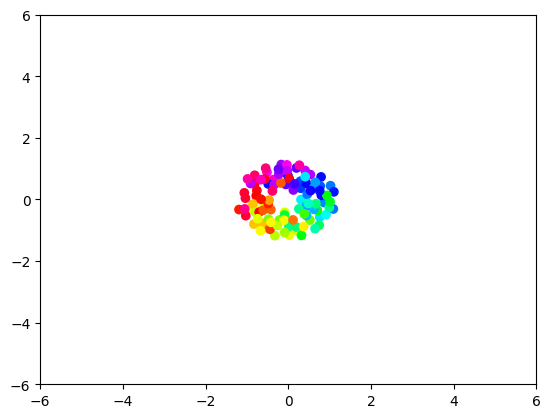

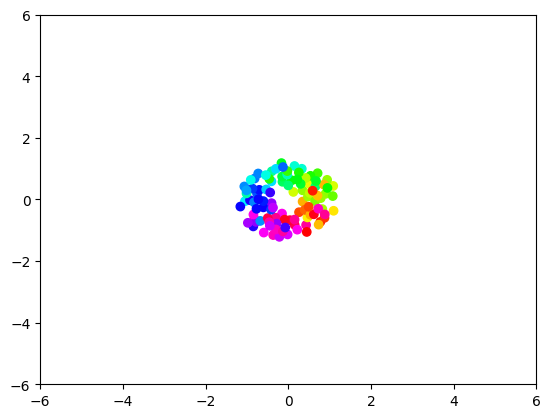

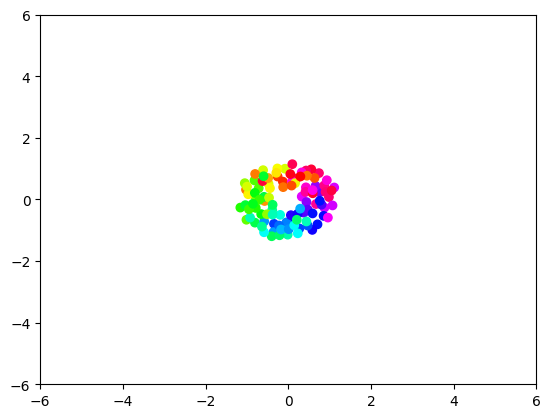

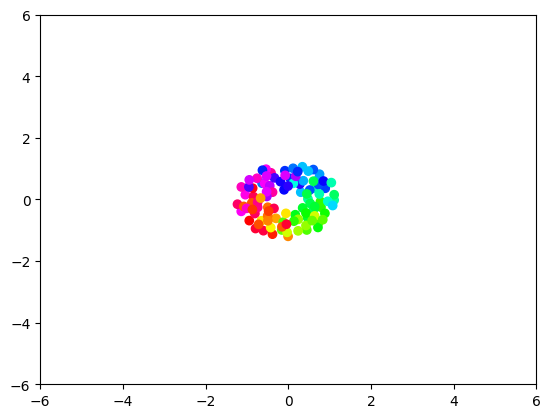

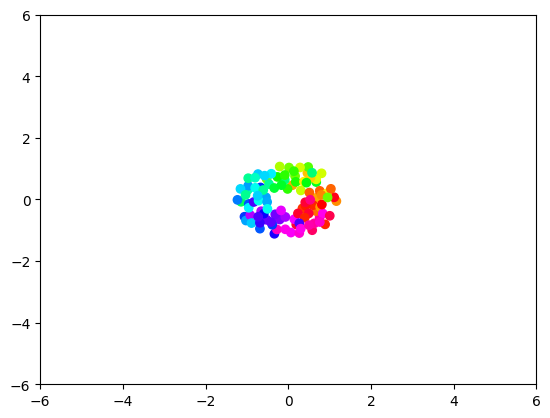

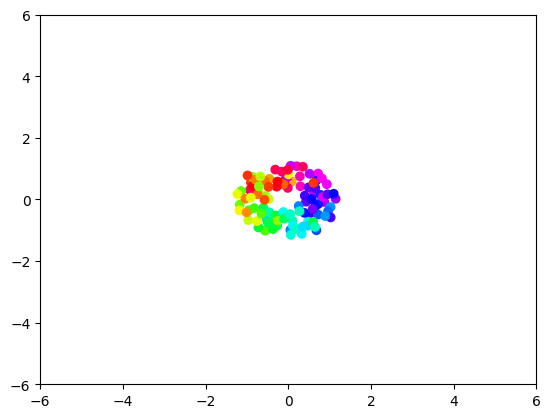

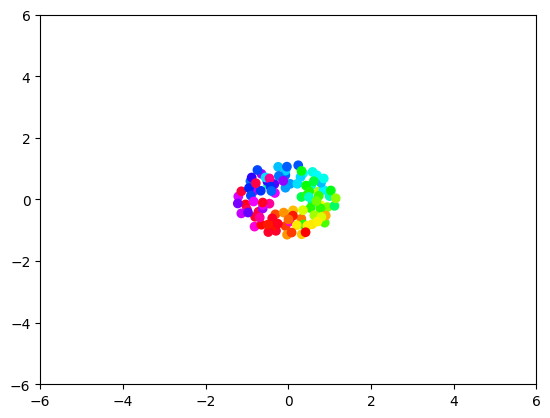

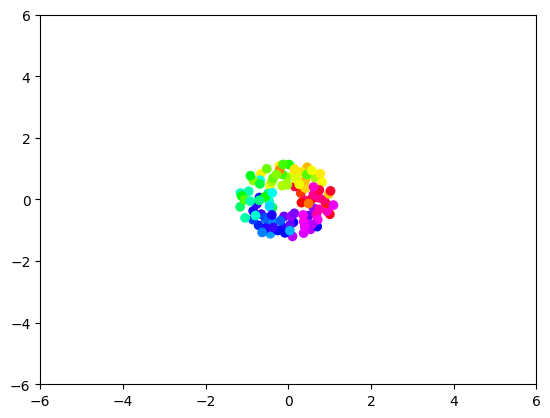

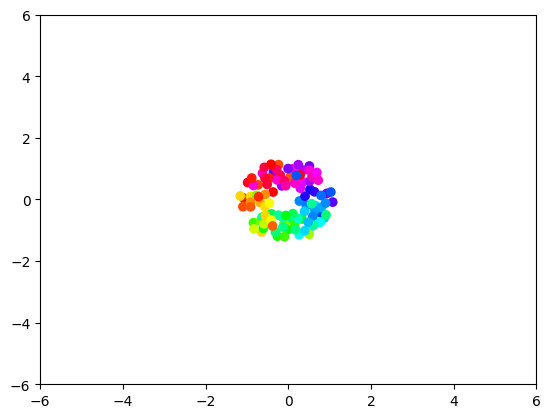

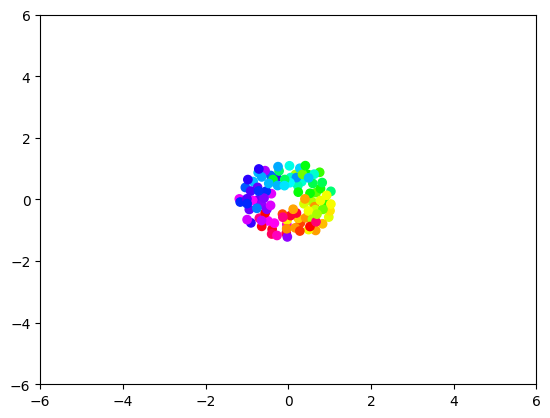

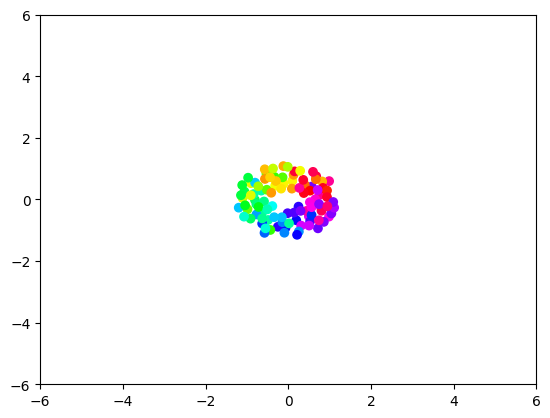

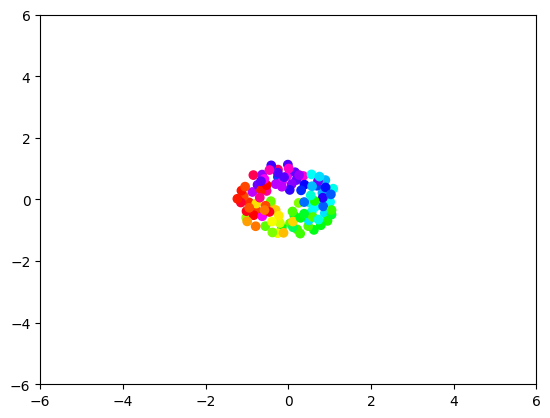

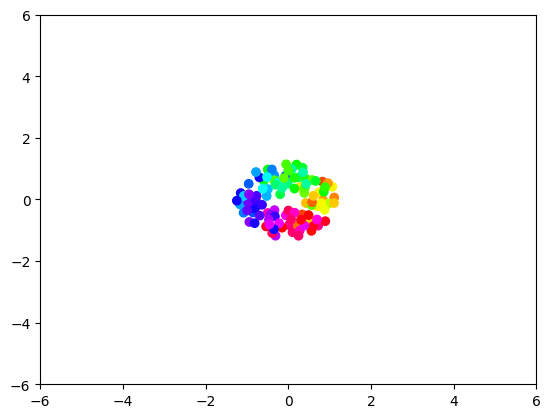

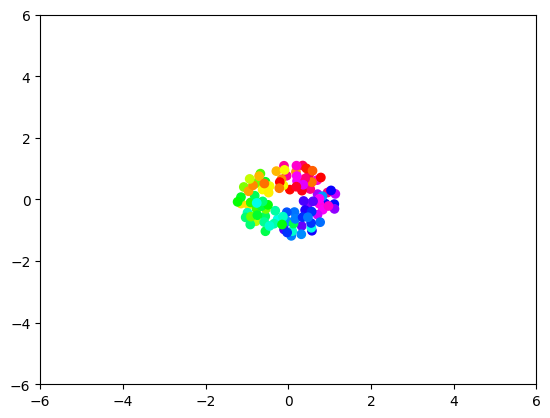

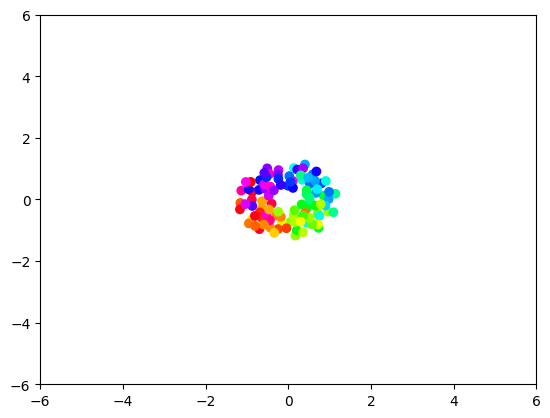

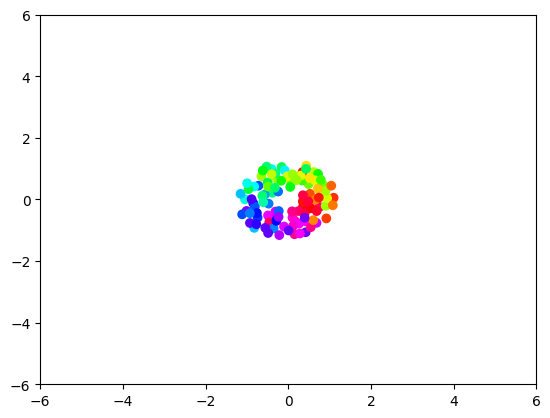

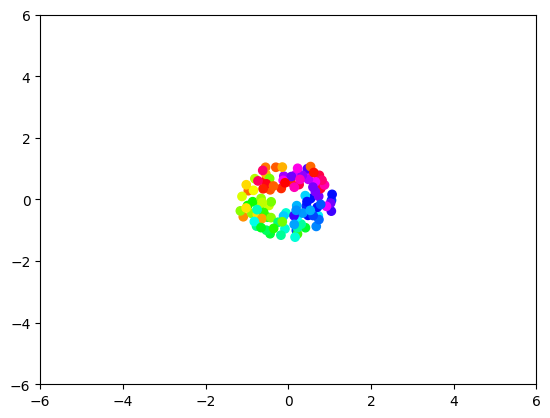

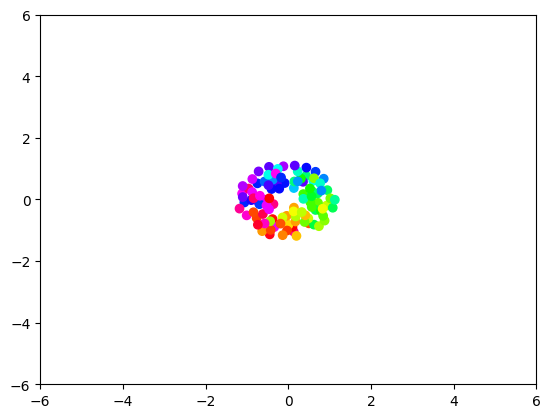

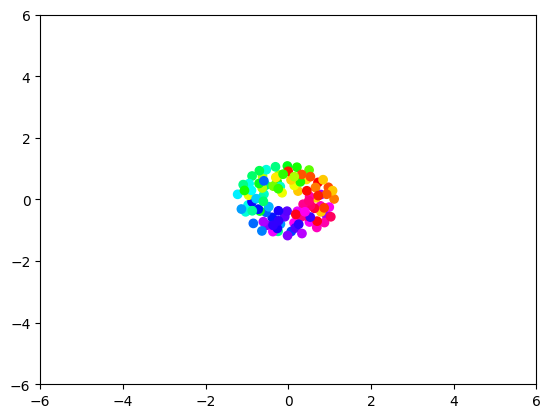

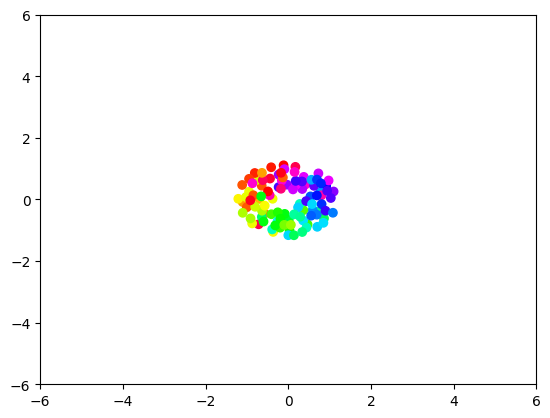

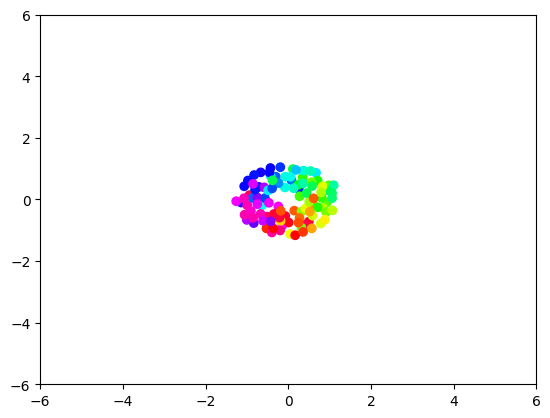

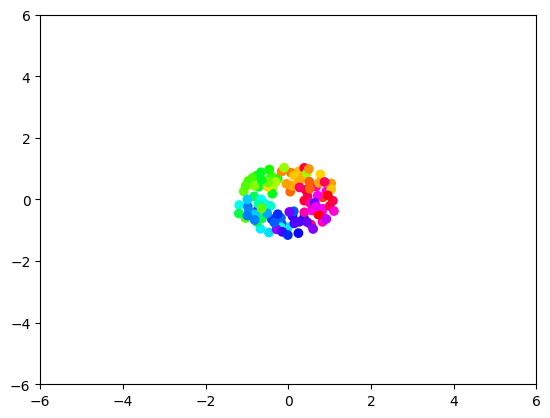

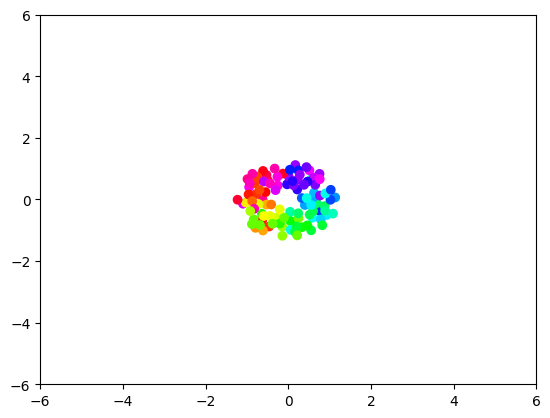

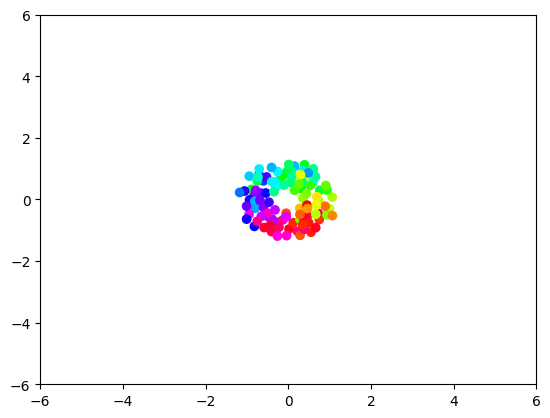

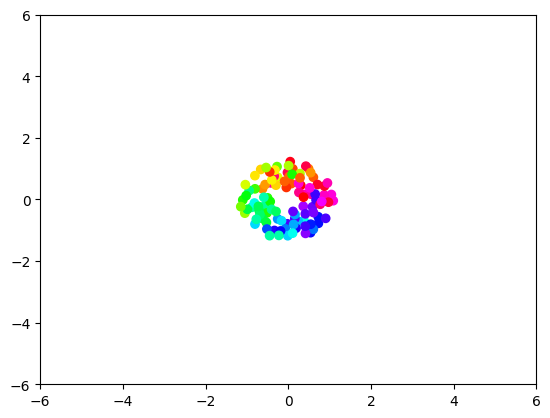

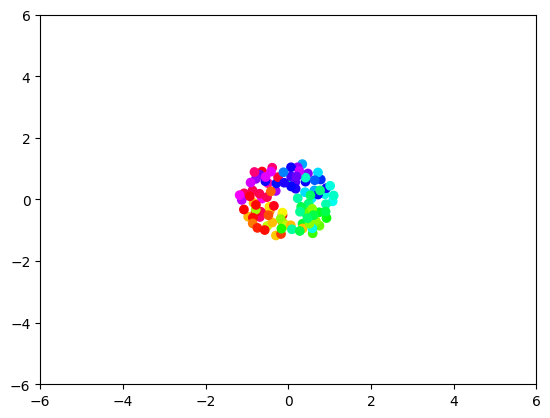

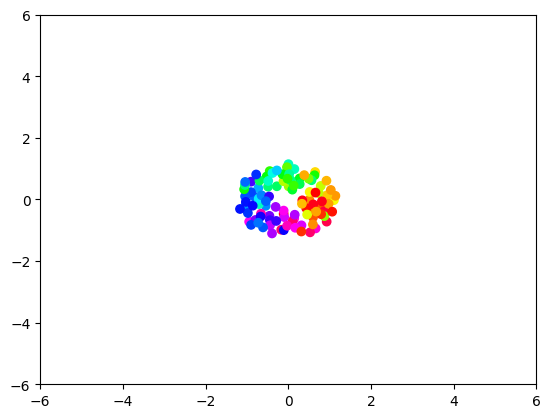

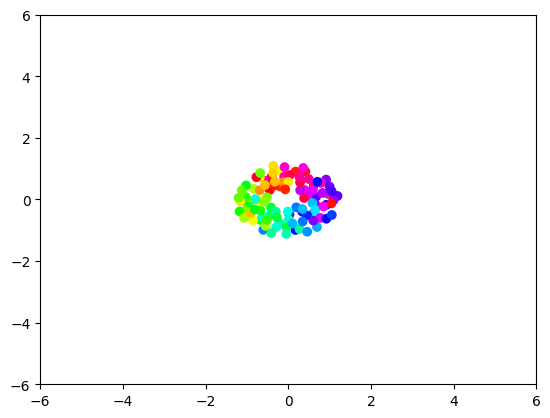

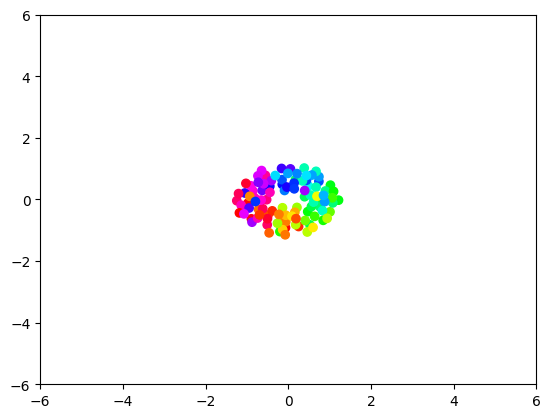

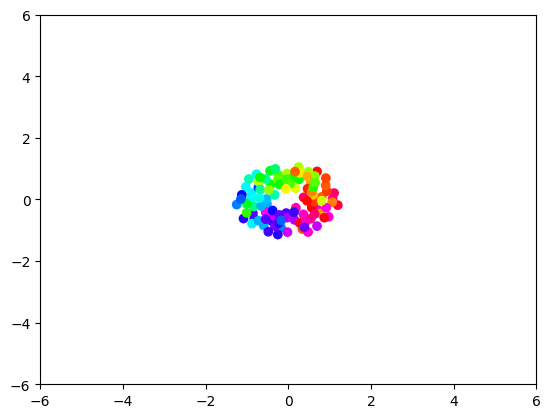

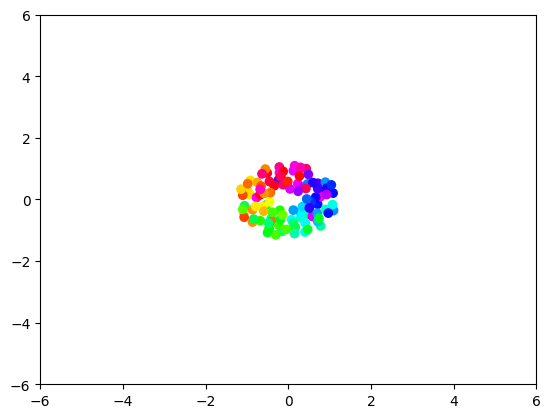

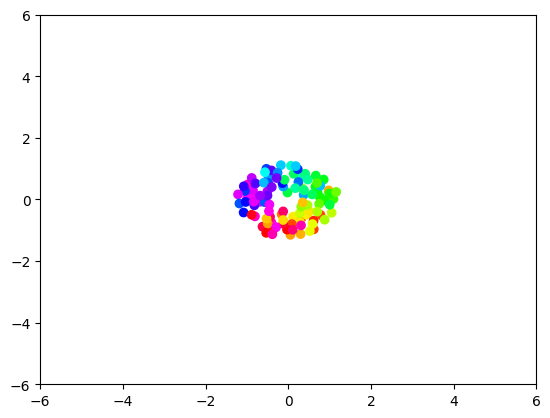

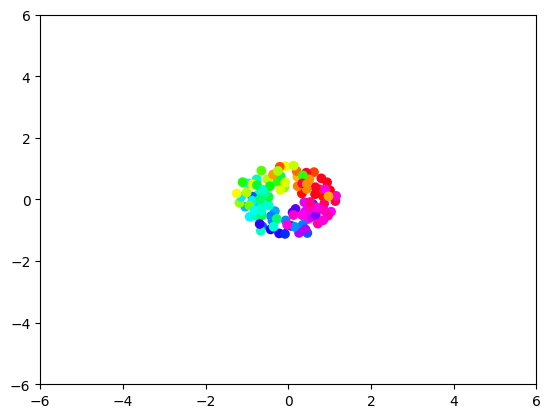

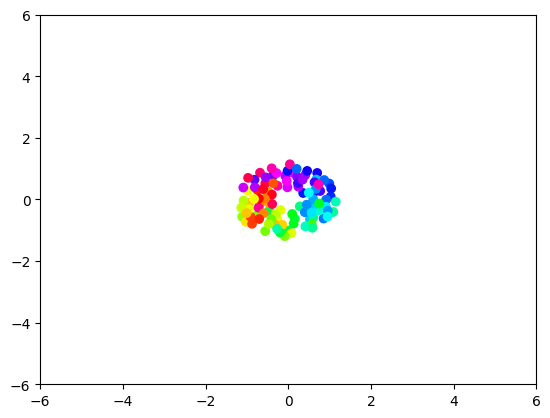

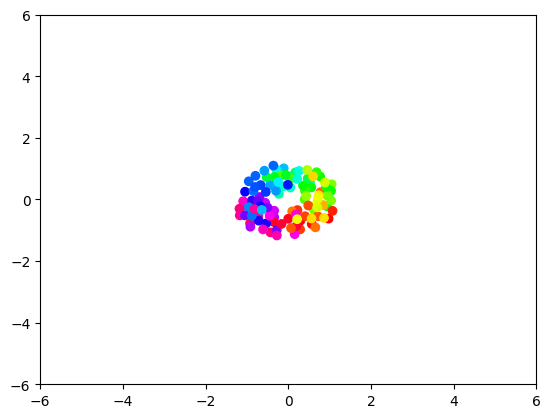

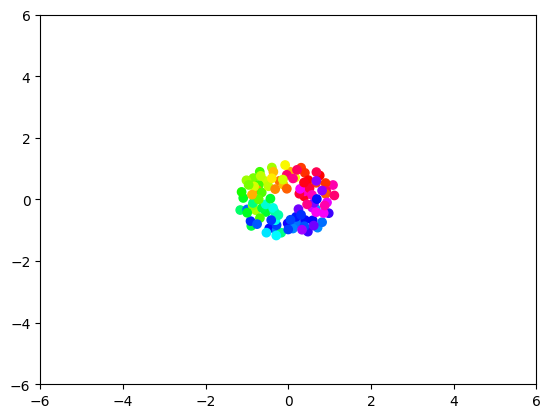

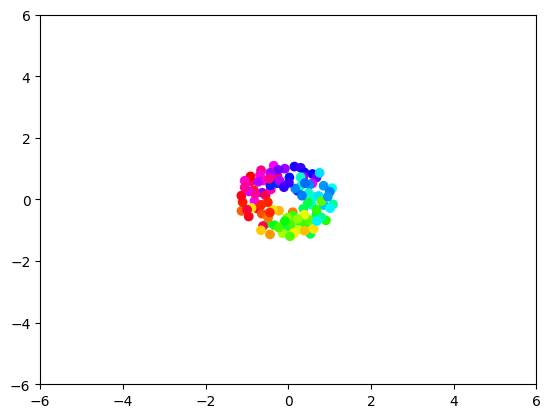

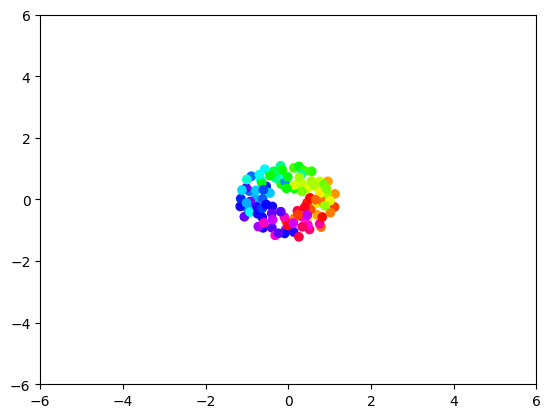

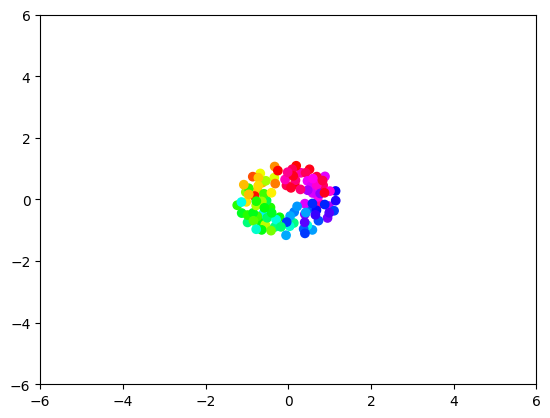

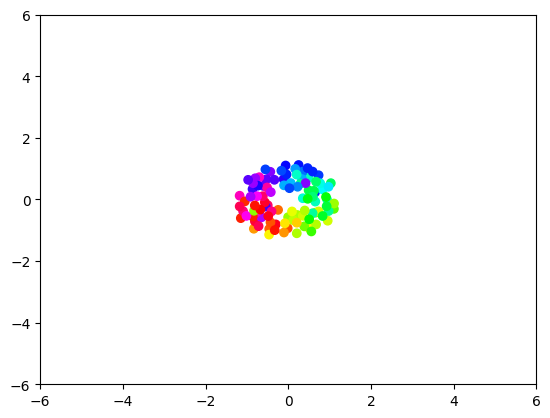

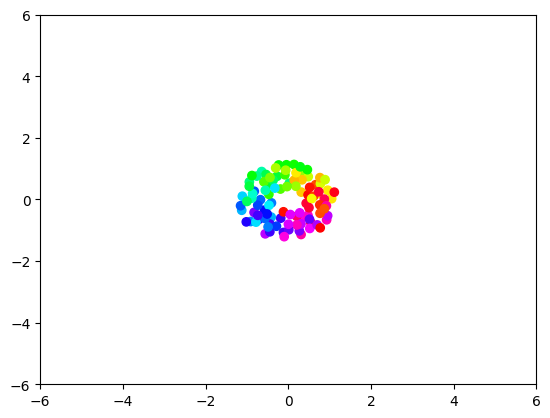

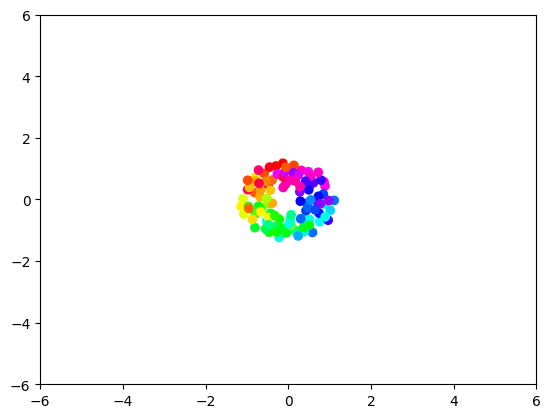

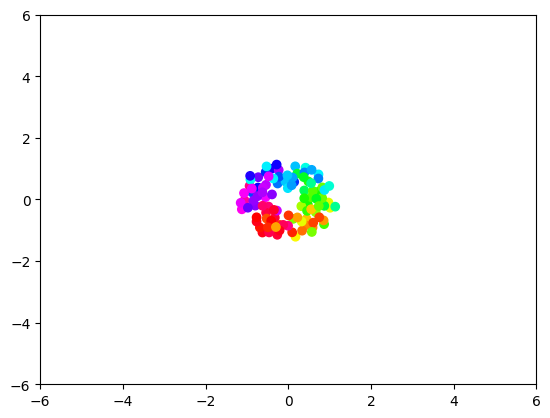

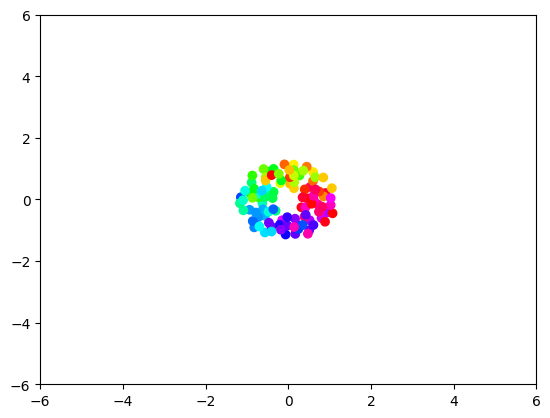

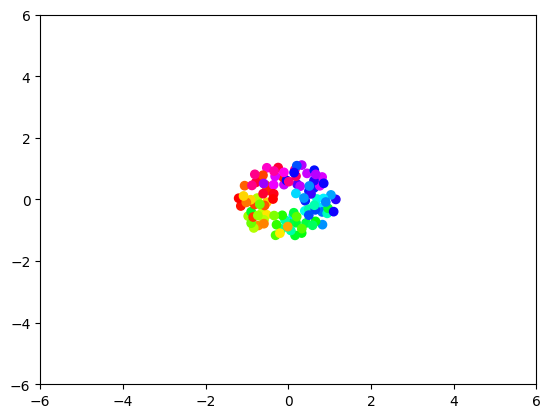

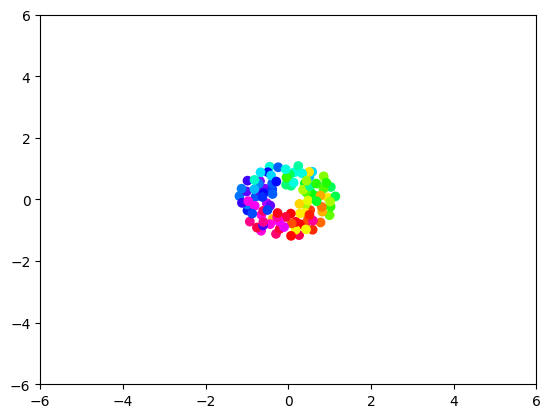

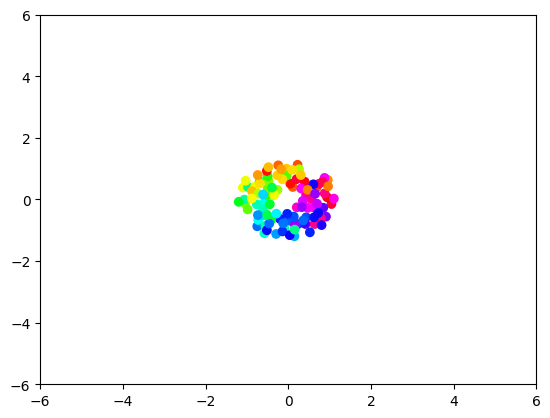

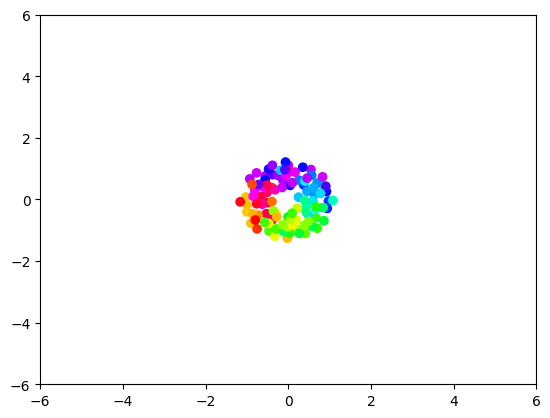

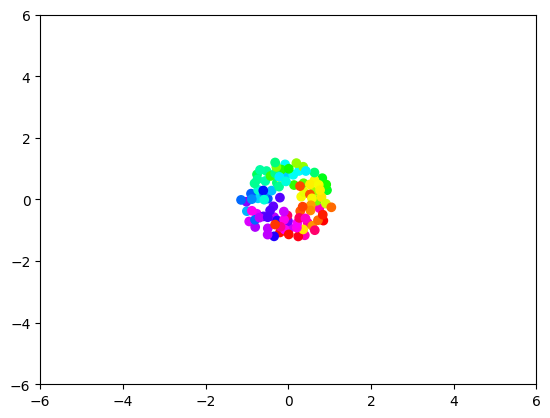

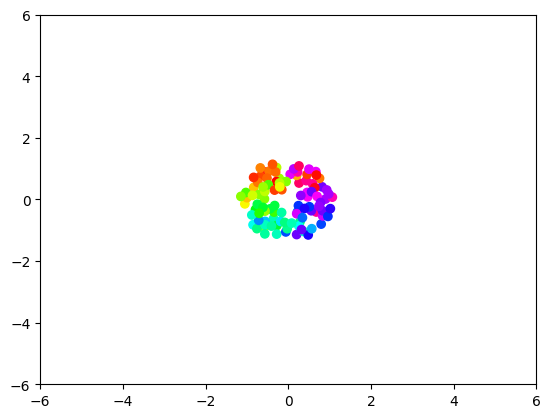

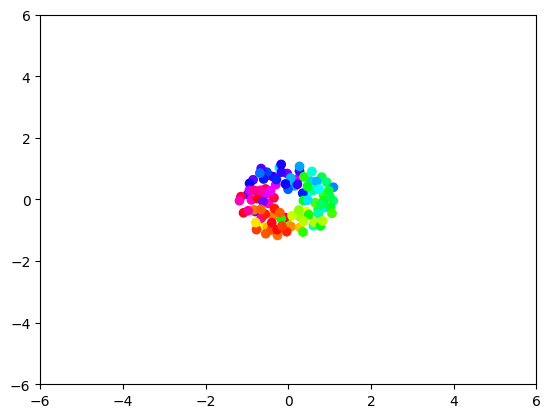

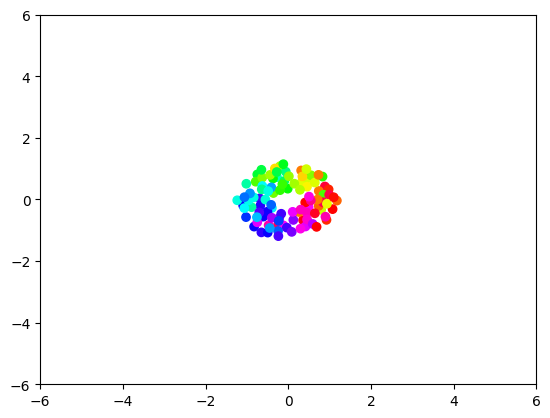

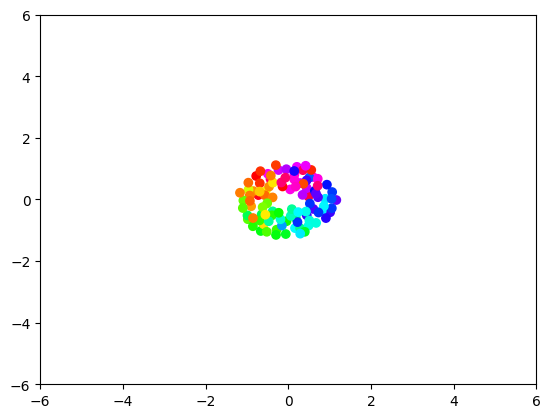

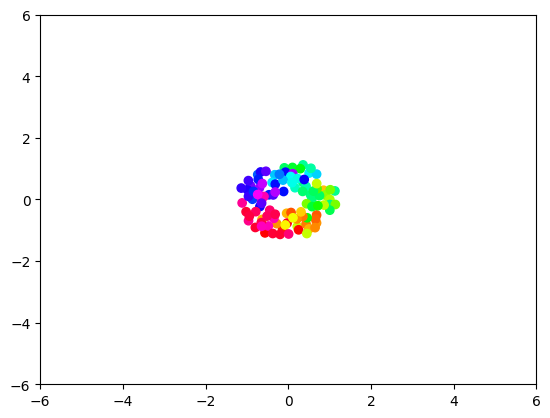

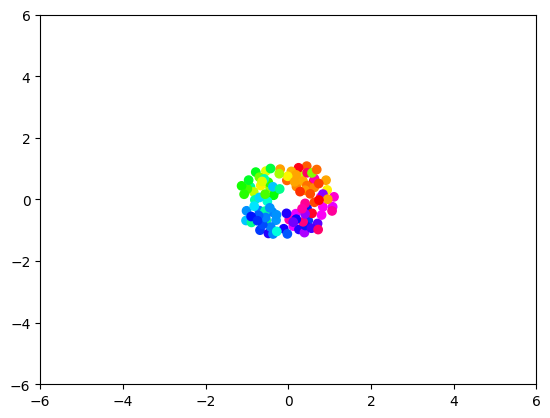

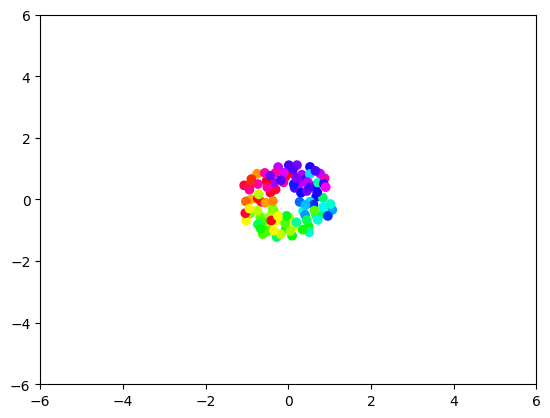

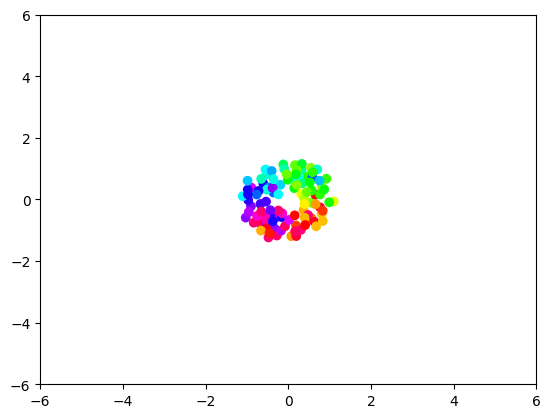

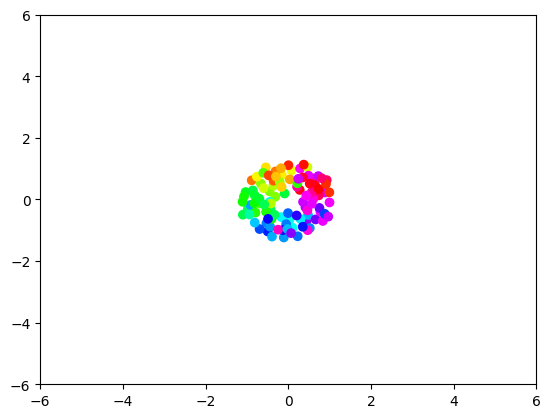

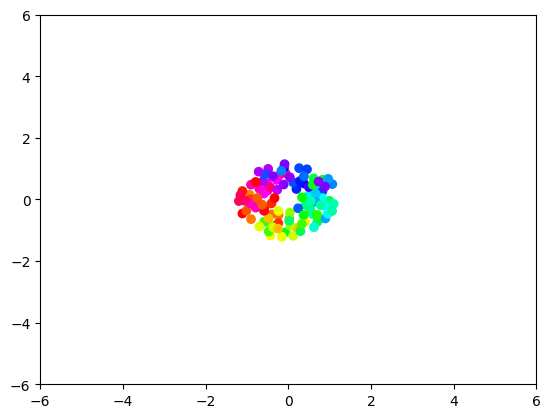

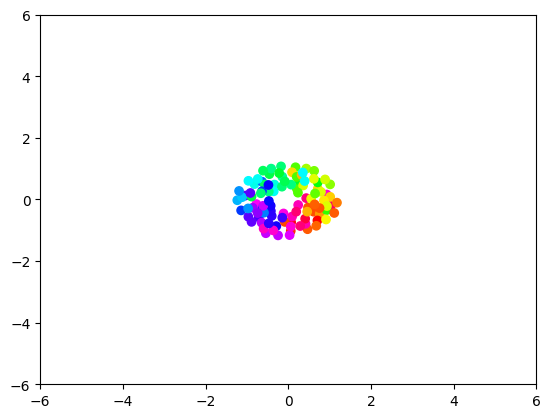

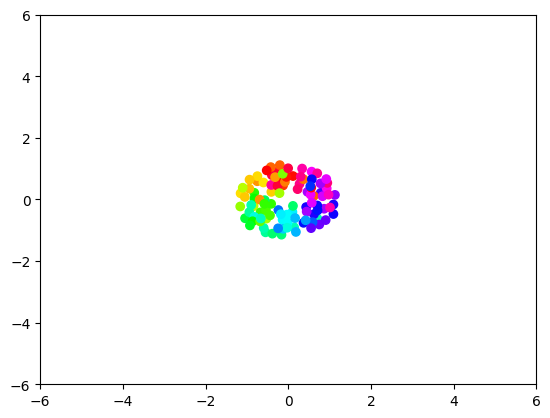

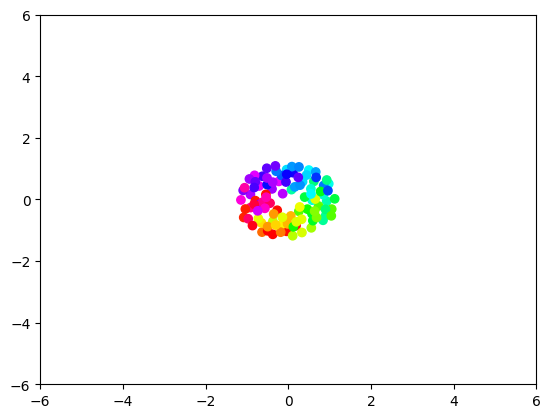

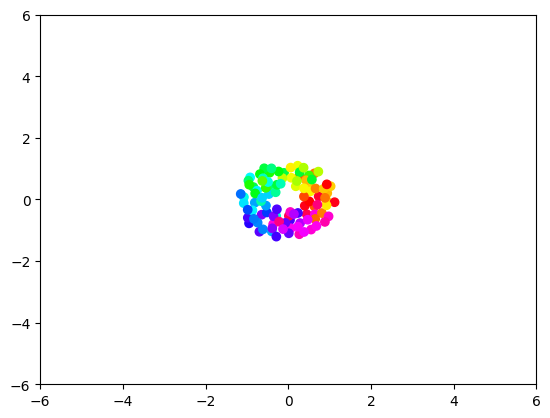

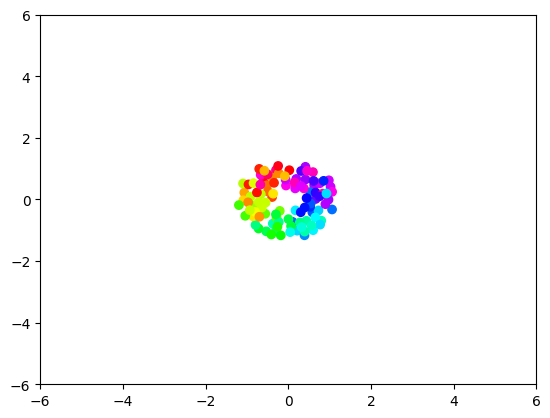

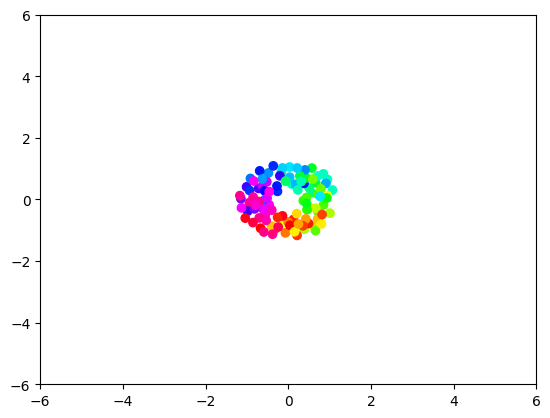

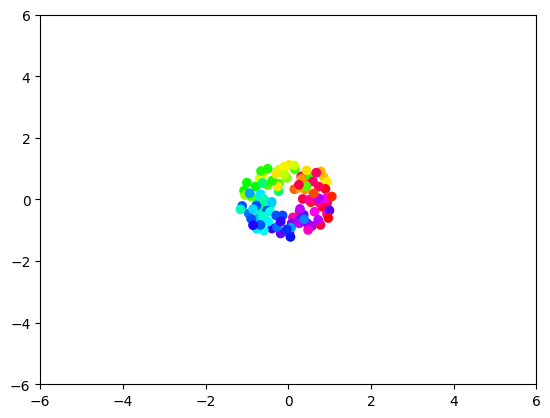

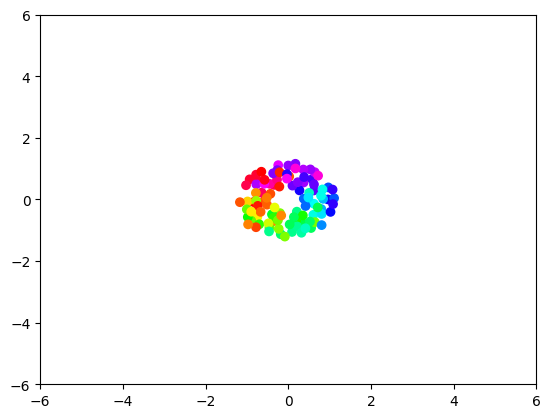

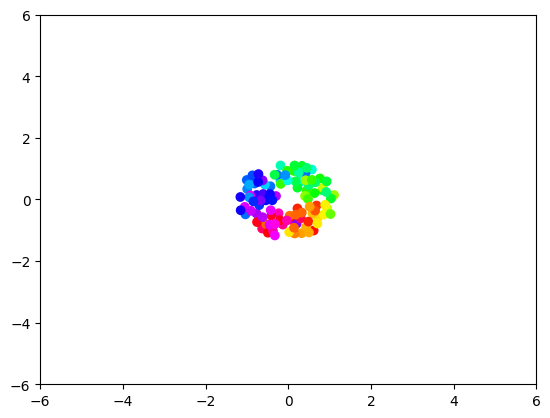

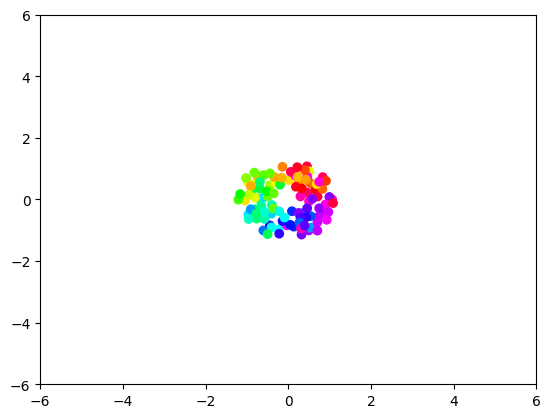

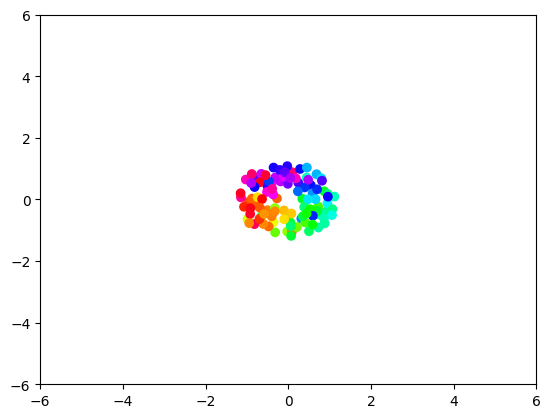

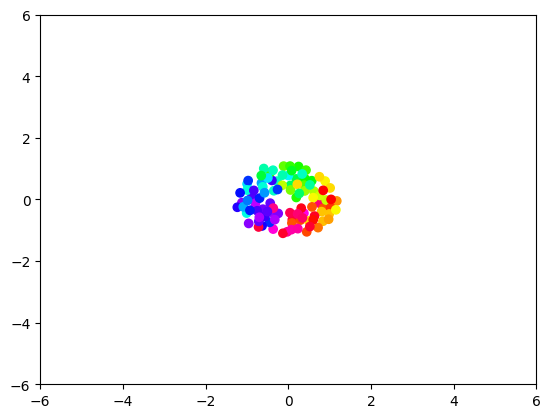

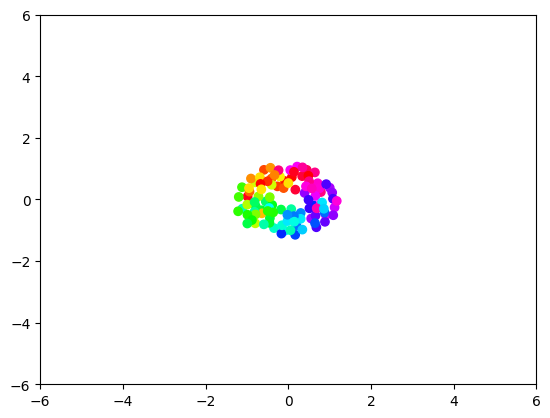

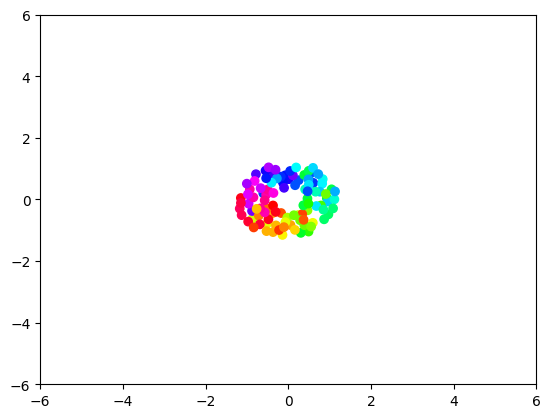

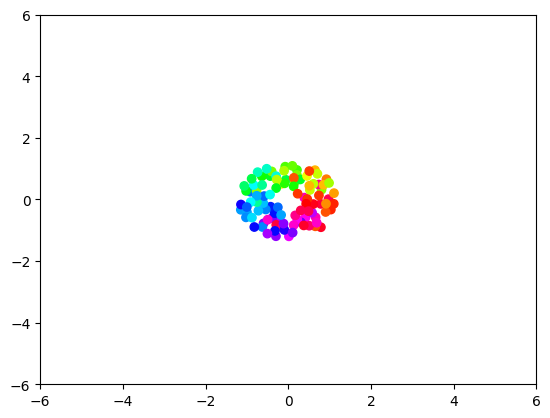

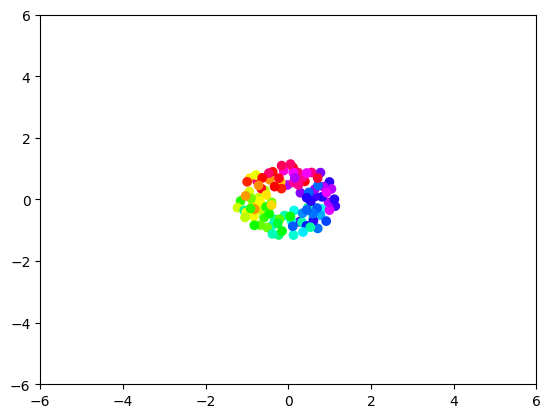

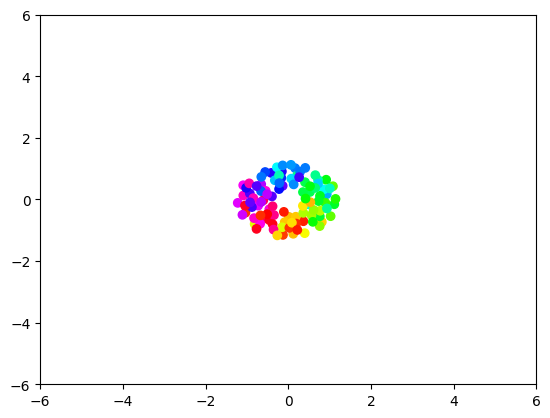

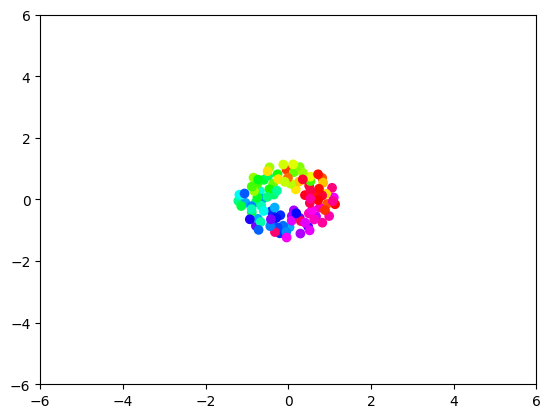

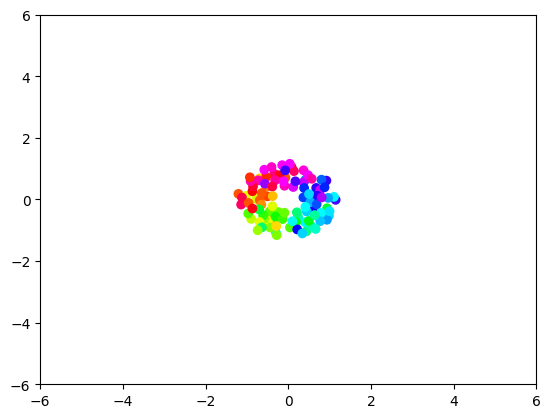

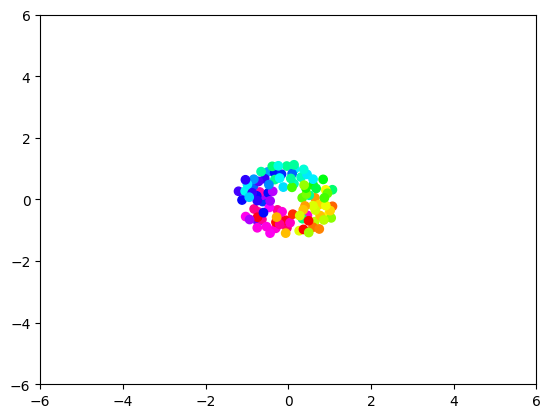

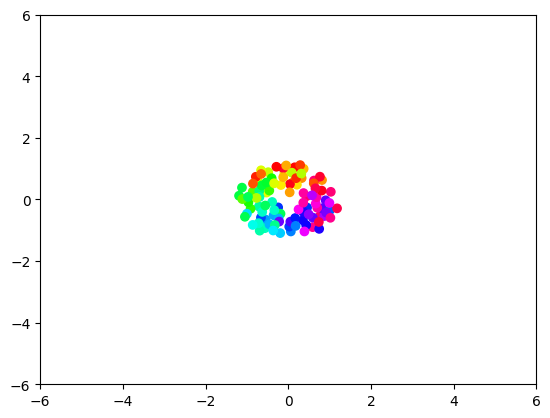

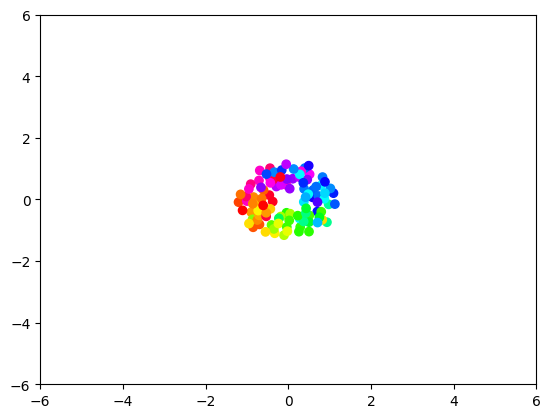

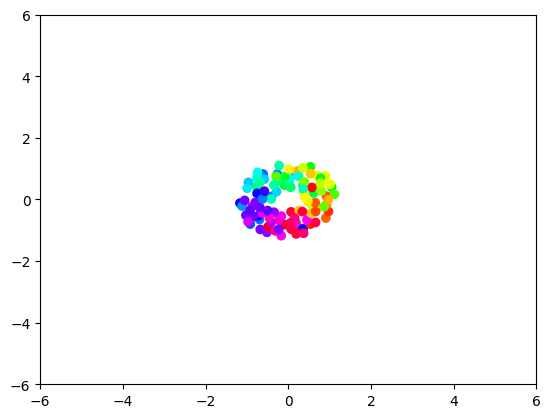

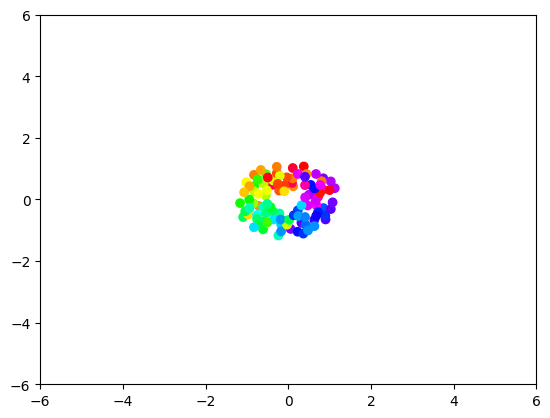

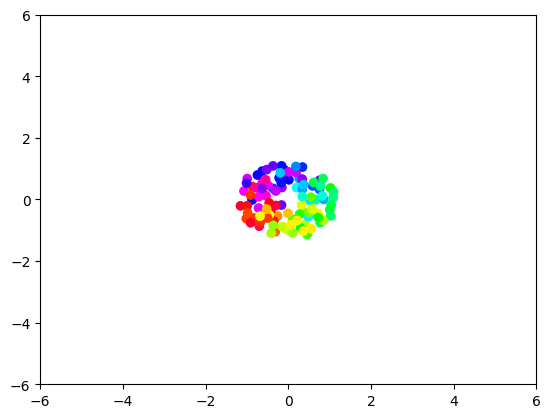

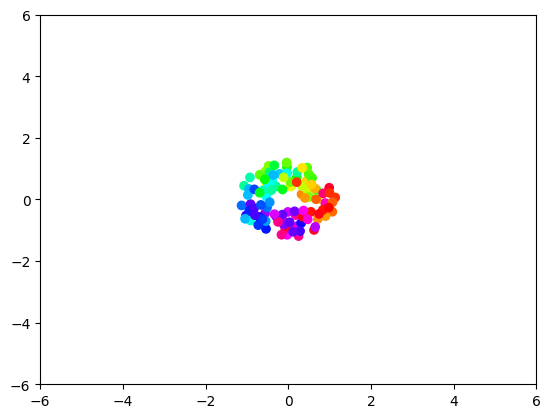

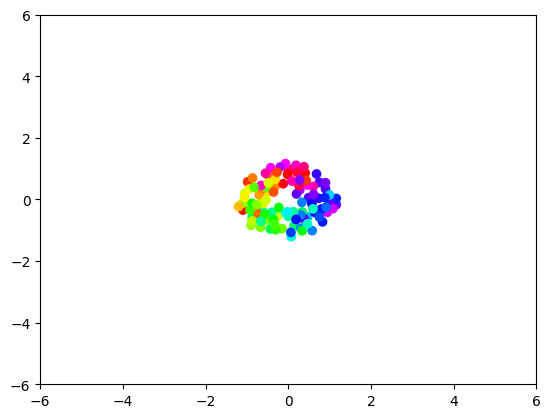

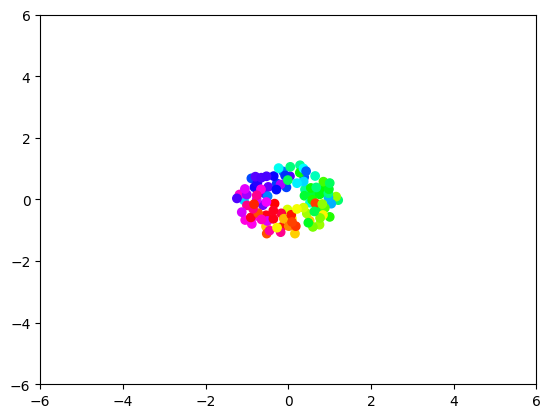

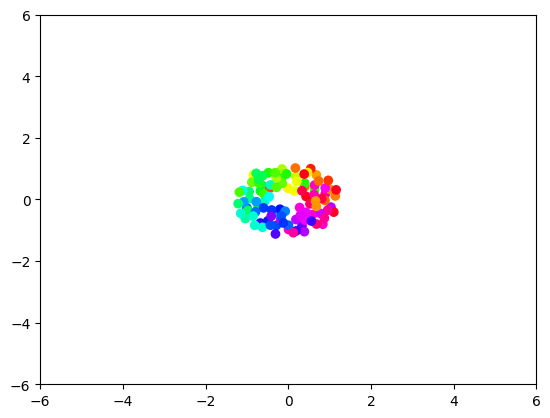

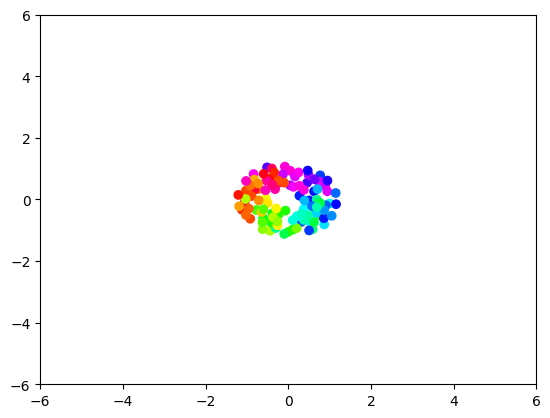

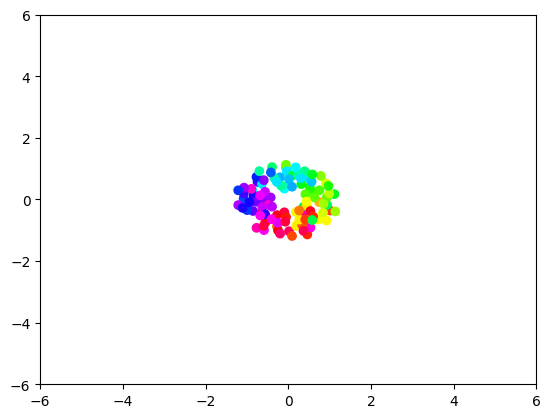

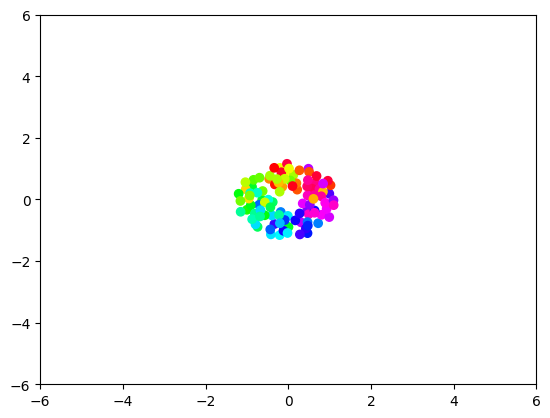

In [3389]:
import matplotlib.pyplot as plt

plt.ion()
steps = 10000

for t in range(steps):
    x, y, theta = step(x, y, theta, dt, J, K)

    if t % 40 == 0:
        plt.clf()
        plt.scatter(x, y, c=theta, cmap="hsv")
        plt.xlim(-6, 6)
        plt.ylim(-6, 6)
        plt.pause(0.01)

plt.show()